
--- Processing AAPL ---
Saved AAPL_historical.csv

--- Processing MSFT ---
Saved MSFT_historical.csv


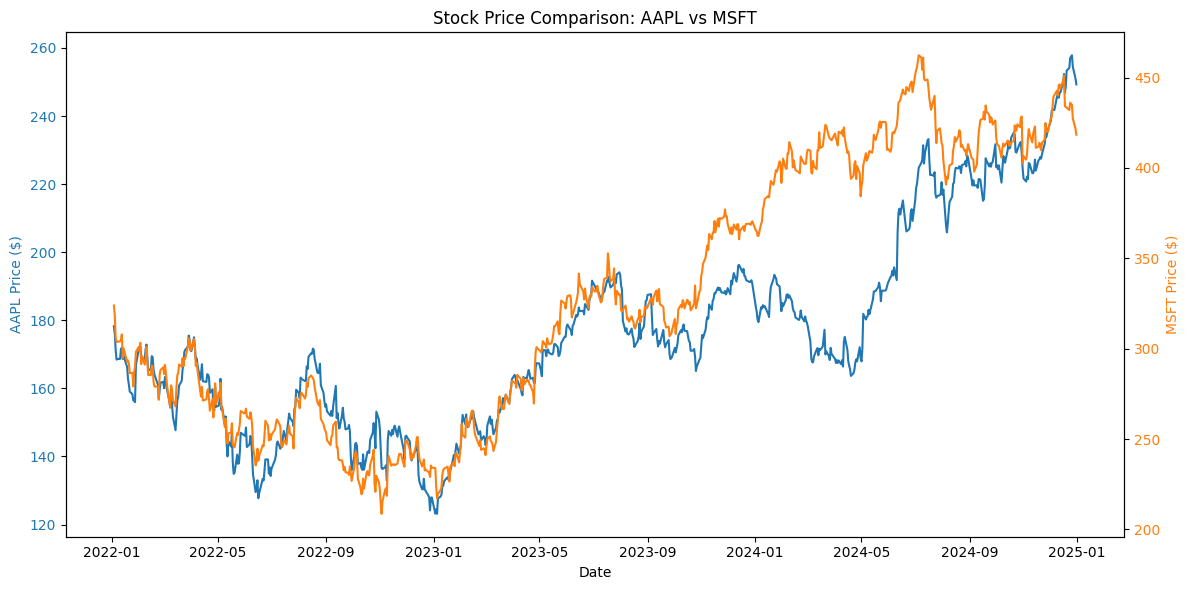

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from utils import ForecastingMetrics
import warnings
warnings.filterwarnings("ignore")


FORECAST_DAYS = 60
START_DATE = '2022-01-01'
END_DATE = '2025-01-01'
INITIAL_LAGS = 5 # To be checked

def get_and_clean_stock_data(ticker_symbol, save_csv=True):
    print(f"\n--- Processing {ticker_symbol} ---")
    
    # Ingestion
    df = yf.download(ticker_symbol, start=START_DATE, end=END_DATE, progress=False)
    
    if df.empty:
        raise ValueError(f"No data found for {ticker_symbol}.")

    # Flatten MultiIndex if necessary
    if isinstance(df.columns, pd.MultiIndex):
        try:
            if 'Close' in df.columns.get_level_values(0):
                df = df.xs('Close', axis=1, level=0, drop_level=True)
            elif 'Close' in df.columns.get_level_values(1):
                df = df.xs('Close', axis=1, level=1, drop_level=True)
        except KeyError:
            pass
            
    if 'Close' in df.columns:
        data = df[['Close']].copy()
    else:
        data = df.iloc[:, 0].to_frame(name='Close')

    # Forward fill missing values
    if data.isnull().values.any():
        print(f"Found {data.isnull().sum()} missing values. Filling...")
        data = data.ffill().bfill()
        
        
    if save_csv:
        filename = f"{ticker_symbol}_historical.csv"
        data.to_csv(filename)
        print(f"Saved {filename}")
    
    return data

# Plot stocks data
def plot_two_stocks(data1, name1, data2, name2):
    fig, ax1 = plt.subplots(figsize=(12, 6))

    color = 'tab:blue'
    ax1.set_xlabel('Date')
    ax1.set_ylabel(f'{name1} Price ($)', color=color)
    ax1.plot(data1.index, data1['Close'], color=color, label=name1)
    ax1.tick_params(axis='y', labelcolor=color)

    ax2 = ax1.twinx()  
    color = 'tab:orange'
    ax2.set_ylabel(f'{name2} Price ($)', color=color)
    ax2.plot(data2.index, data2['Close'], color=color, label=name2)
    ax2.tick_params(axis='y', labelcolor=color)

    plt.title(f'Stock Price Comparison: {name1} vs {name2}')
    fig.tight_layout()
    plt.show()


MY_STOCKS = ['AAPL', 'MSFT'] 
stock_data_store = {}

for ticker in MY_STOCKS:
    stock_data_store[ticker] = get_and_clean_stock_data(ticker)

plot_two_stocks(
    stock_data_store[MY_STOCKS[0]], MY_STOCKS[0],
    stock_data_store[MY_STOCKS[1]], MY_STOCKS[1]
)

# Tset (dont mind)

In [24]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
import scipy.optimize as sco

# Custom Modules
from backtest import Backtest
from utils import PortfolioEvaluator, TradingMetrics

import warnings
warnings.filterwarnings("ignore")

# --- HACKATHON CONFIGURATION ---
my_stocks = ['AAPL', 'MSFT'] 

start_date = '2022-01-01'
end_date = '2025-01-01'
forecast_days = 60

# SEASONALITY: 5 days (Weekly trading cycle)
seasonal_period = 5 

# LAGS: Fixed at 60 (approx. 3 months/1 quarter of history)
lags = 63            
capital = 10000

In [25]:
def get_data(ticker):
    print(f"Fetching data for {ticker}...")
    df = yf.download(ticker, start=start_date, end=end_date, progress=False)
    
    if isinstance(df.columns, pd.MultiIndex):
        df = df.xs(ticker, axis=1, level=1)
        
    # STRATEGY: ORDINAL TIME
    # We strictly drop missing data (weekends/holidays).
    df = df.dropna()
    
    return df[['Close']]

stock_data = {ticker: get_data(ticker) for ticker in my_stocks}
print("Data ingestion complete (Ordinal Trading Days).")

Fetching data for AAPL...
Fetching data for MSFT...
Data ingestion complete (Ordinal Trading Days).


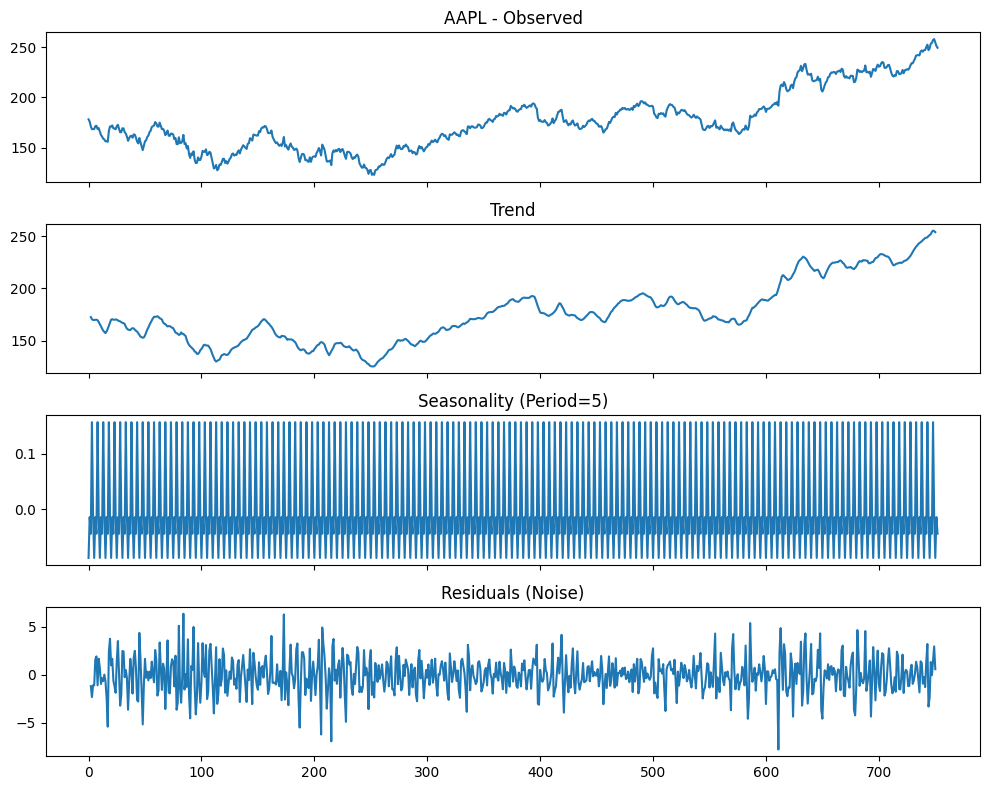


--- Stationarity Tests for AAPL Residuals ---
ADF p-value:  0.0000 (Stationary)
KPSS p-value: 0.0521 (Stationary)

--- ACF/PACF Diagnostics for AAPL ---


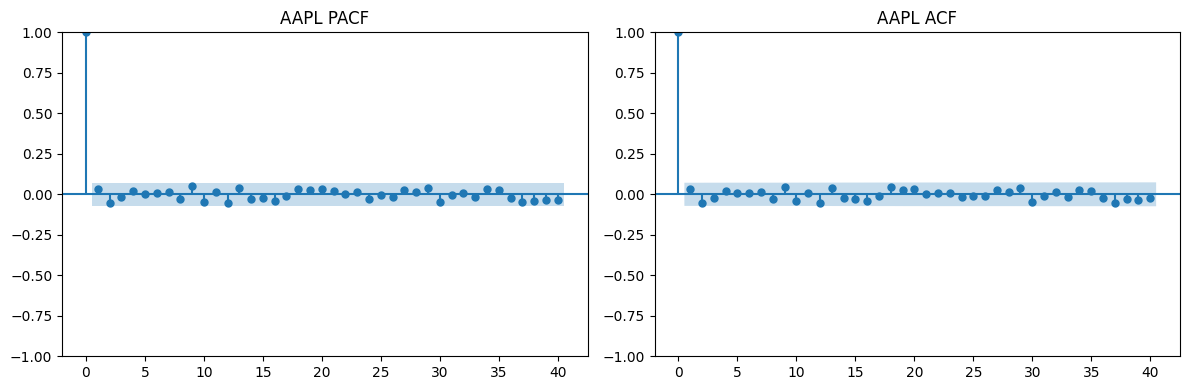

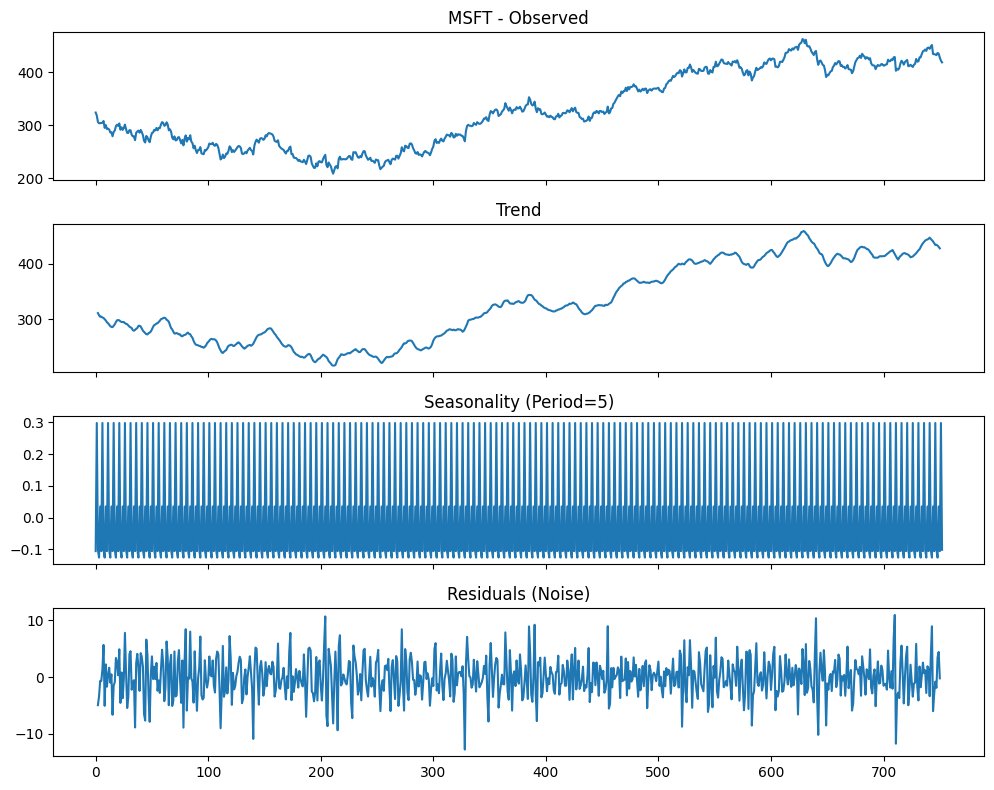


--- Stationarity Tests for MSFT Residuals ---
ADF p-value:  0.0000 (Stationary)
KPSS p-value: 0.0417 (Non-Stationary)

--- ACF/PACF Diagnostics for MSFT ---


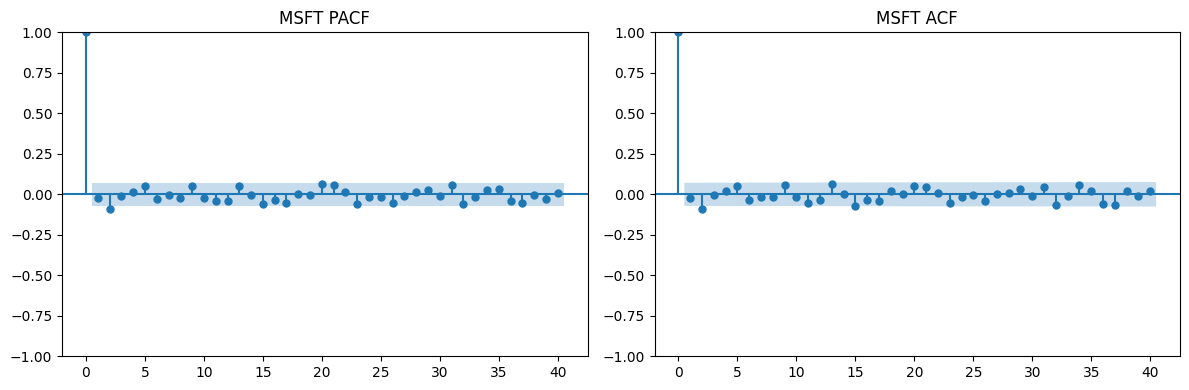

In [26]:
def diagnose_stock(ticker, df, period):
    series = df['Close']
    
    # Decompose
    decomp = seasonal_decompose(series.values, model='additive', period=period)
    
    fig, axes = plt.subplots(4, 1, figsize=(10, 8), sharex=True)
    axes[0].plot(series.values); axes[0].set_title(f'{ticker} - Observed')
    axes[1].plot(decomp.trend); axes[1].set_title('Trend')
    axes[2].plot(decomp.seasonal); axes[2].set_title(f'Seasonality (Period={period})')
    axes[3].plot(decomp.resid); axes[3].set_title('Residuals (Noise)')
    plt.tight_layout()
    plt.show()
    
    # Stationarity Tests on Residuals
    resid = pd.Series(decomp.resid).dropna()
    print(f"\n--- Stationarity Tests for {ticker} Residuals ---")
    
    adf_p = adfuller(resid)[1]
    is_adf_stat = adf_p < 0.05
    print(f"ADF p-value:  {adf_p:.4f} ({'Stationary' if is_adf_stat else 'Non-Stationary'})")
    
    kpss_p = kpss(resid, regression='c', nlags="auto")[1]
    is_kpss_stat = kpss_p > 0.05
    print(f"KPSS p-value: {kpss_p:.4f} ({'Stationary' if is_kpss_stat else 'Non-Stationary'})")

    if is_kpss_stat and not is_adf_stat:
        print(f"⚠️ CAUTION: Conflict detected. Visual inspection recommended.")

    print(f"\n--- ACF/PACF Diagnostics for {ticker} ---")
    sa_series = pd.Series(series.values - decomp.seasonal)
    diff_sa_series = sa_series.diff().dropna()

    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    plot_pacf(diff_sa_series, lags=40, ax=ax[0], method='ywm')
    ax[0].set_title(f"{ticker} PACF")
    plot_acf(diff_sa_series, lags=40, ax=ax[1])
    ax[1].set_title(f"{ticker} ACF")
    plt.tight_layout()
    plt.show()

for ticker in my_stocks:
    diagnose_stock(ticker, stock_data[ticker], seasonal_period)

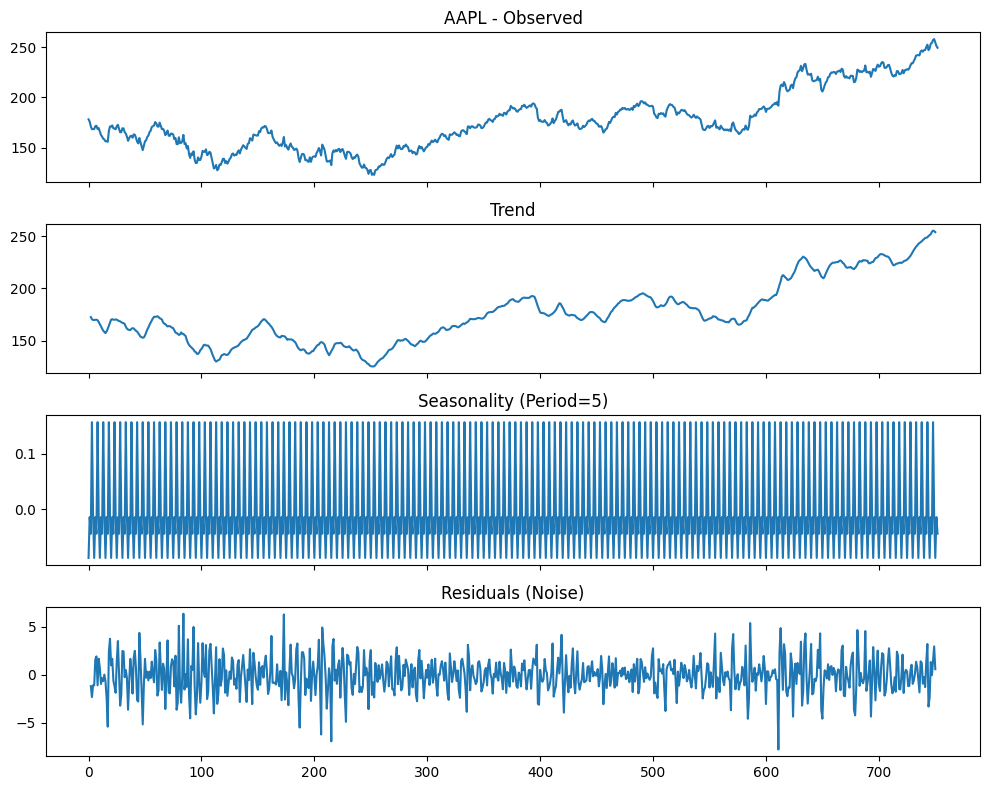


--- Stationarity Tests for AAPL Residuals ---
ADF p-value:  0.0000 (Stationary)
KPSS p-value: 0.0521 (Stationary)
⚠️ Conflict detected. Use caution and inspect visually.

--- Stationarity Tests for AAPL Seasonally Adjusted Series (1st Diff) ---
ADF p-value:  0.0000 (Stationary)
KPSS p-value: 0.1000 (Stationary)

--- ACF/PACF Diagnostics for AAPL (1st Difference of Seasonally Adjusted) ---


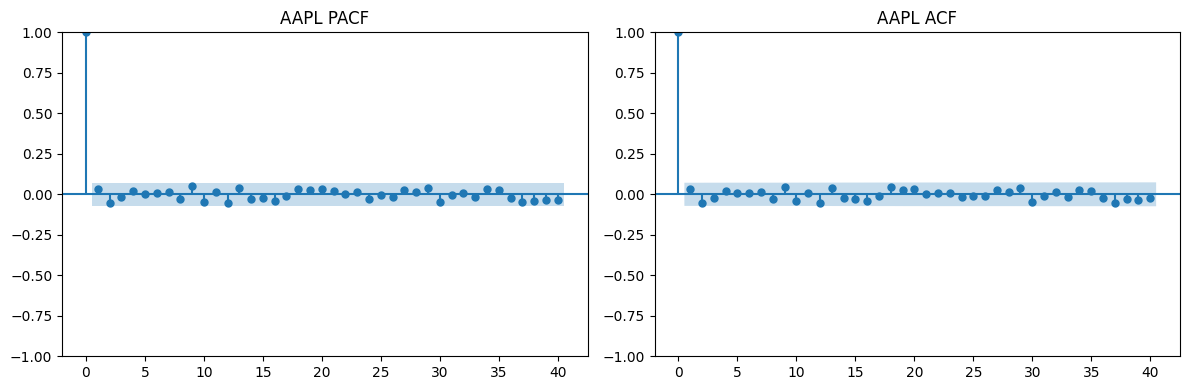

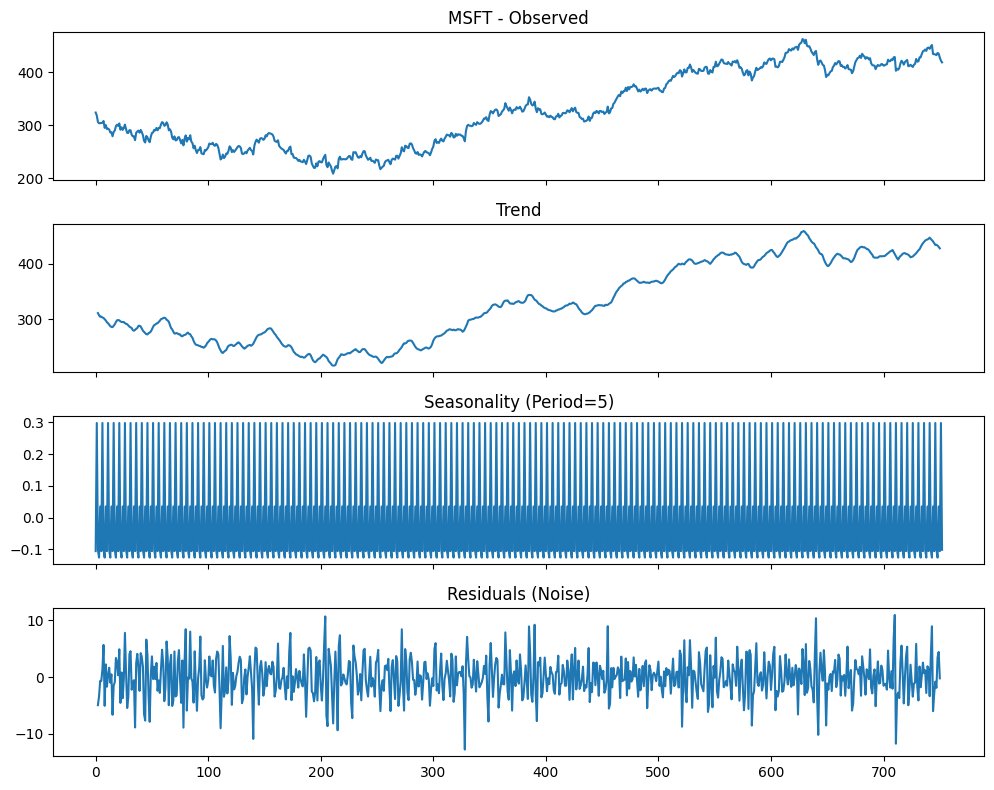


--- Stationarity Tests for MSFT Residuals ---
ADF p-value:  0.0000 (Stationary)
KPSS p-value: 0.0417 (Non-Stationary)
✅ Both tests agree: series is stationary.

--- Stationarity Tests for MSFT Seasonally Adjusted Series (1st Diff) ---
ADF p-value:  0.0000 (Stationary)
KPSS p-value: 0.1000 (Stationary)

--- ACF/PACF Diagnostics for MSFT (1st Difference of Seasonally Adjusted) ---


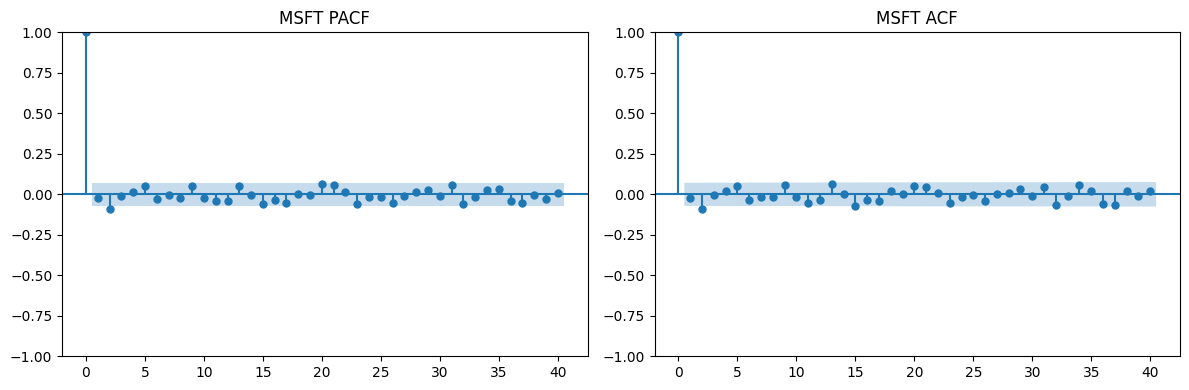

In [27]:
import matplotlib.pyplot as plt
import pandas as pd
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

def diagnose_stock(ticker, df, period):
    series = df['Close']
    
    # 1. Seasonal Decomposition
    decomp = seasonal_decompose(series.values, model='additive', period=period)
    
    fig, axes = plt.subplots(4, 1, figsize=(10, 8), sharex=True)
    axes[0].plot(series.values); axes[0].set_title(f'{ticker} - Observed')
    axes[1].plot(decomp.trend); axes[1].set_title('Trend')
    axes[2].plot(decomp.seasonal); axes[2].set_title(f'Seasonality (Period={period})')
    axes[3].plot(decomp.resid); axes[3].set_title('Residuals (Noise)')
    plt.tight_layout()
    plt.show()

    # 2. Residuals Stationarity Test
    resid = pd.Series(decomp.resid).dropna()
    print(f"\n--- Stationarity Tests for {ticker} Residuals ---")
    
    adf_p = adfuller(resid)[1]
    kpss_p = kpss(resid, regression='c', nlags="auto")[1]
    print(f"ADF p-value:  {adf_p:.4f} ({'Stationary' if adf_p < 0.05 else 'Non-Stationary'})")
    print(f"KPSS p-value: {kpss_p:.4f} ({'Stationary' if kpss_p > 0.05 else 'Non-Stationary'})")
    
    if (kpss_p > 0.05) and (adf_p >= 0.05):
        print(f"⚠️ Both tests indicate non-stationarity.")
    elif (kpss_p < 0.05) and (adf_p < 0.05):
        print(f"✅ Both tests agree: series is stationary.")
    else:
        print(f"⚠️ Conflict detected. Use caution and inspect visually.")

    # 3. Stationarity of Seasonally Adjusted Series
    sa_series = pd.Series(series.values - decomp.seasonal).dropna()
    diff_sa_series = sa_series.diff().dropna()

    print(f"\n--- Stationarity Tests for {ticker} Seasonally Adjusted Series (1st Diff) ---")
    adf_p_sa = adfuller(diff_sa_series)[1]
    kpss_p_sa = kpss(diff_sa_series, regression='c', nlags="auto")[1]
    print(f"ADF p-value:  {adf_p_sa:.4f} ({'Stationary' if adf_p_sa < 0.05 else 'Non-Stationary'})")
    print(f"KPSS p-value: {kpss_p_sa:.4f} ({'Stationary' if kpss_p_sa > 0.05 else 'Non-Stationary'})")

    # 4. ACF/PACF of Differenced Seasonally Adjusted Series
    print(f"\n--- ACF/PACF Diagnostics for {ticker} (1st Difference of Seasonally Adjusted) ---")
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    plot_pacf(diff_sa_series, lags=40, ax=ax[0], method='ywm')
    ax[0].set_title(f"{ticker} PACF")
    plot_acf(diff_sa_series, lags=40, ax=ax[1])
    ax[1].set_title(f"{ticker} ACF")
    plt.tight_layout()
    plt.show()

for ticker in my_stocks:
    diagnose_stock(ticker, stock_data[ticker], seasonal_period)


In [28]:
def make_lagged(series, n_lags):
    s = pd.Series(series).reset_index(drop=True)
    df = pd.DataFrame({'y': s})
    for i in range(1, n_lags+1):
        df[f'lag_{i}'] = s.shift(i)
    return df.dropna()

def recursive_forecast(last_window, model, steps, feature_names):
    preds = []
    current_window = list(last_window)
    for _ in range(steps):
        input_df = pd.DataFrame([current_window], columns=feature_names)
        pred = model.predict(input_df)[0]
        preds.append(pred)
        current_window.pop(0)
        current_window.append(pred)
    return np.array(preds)

def train_and_validate(ticker, df, period, n_lags, steps):
    print(f"\n=== Modeling {ticker} (Ordinal: Trend + Seasonal + Residuals) ===")
    series = df['Close']
    
    # --- STEP 1: DECOMPOSE ---
    decomp = seasonal_decompose(series.values, model='multiplicative', period=period)
    
    # 1. Seasonal
    seasonal = pd.Series(decomp.seasonal).dropna()
    seasonal_cycle = seasonal.iloc[-period:].values
    
    # 2. Trend (Linear Reg)
    time_idx = np.arange(len(series)).reshape(-1, 1)
    trend_model = LinearRegression()
    trend_model.fit(time_idx, series.values)
    trend_line = trend_model.predict(time_idx)
    
    # 3. Residuals
    residuals = series.values - trend_line - decomp.seasonal
    residuals = pd.Series(residuals).fillna(0)

    # --- STEP 2: SPLIT ---
    split_idx = len(series) - steps
    df_lagged = make_lagged(residuals, n_lags)
    X = df_lagged.drop(columns='y')
    y = df_lagged['y']
    
    train_size = split_idx - n_lags
    X_train, X_test = X.iloc[:train_size], X.iloc[train_size:train_size+steps]
    y_train = y.iloc[:train_size]
    
    # --- STEP 3: FORECAST COMPONENTS ---
    future_time = np.arange(len(series), len(series) + steps).reshape(-1, 1)
    future_trend = trend_model.predict(future_time)
    future_seasonal = np.tile(seasonal_cycle, int(np.ceil(steps/period)))[:steps]
    
    # --- STEP 4: MODEL RESIDUALS ---
    preds = {}
    
    # Model 1: ARIMA (High Order for Momentum)
    try:
        # (5,0,5) forces it to look back 5 days to capture momentum
        arima = ARIMA(residuals.iloc[:split_idx].values, order=(5,0,5)).fit() 
        p_resid_arima = arima.forecast(steps=steps)
        preds['ARIMA'] = future_trend + future_seasonal + p_resid_arima
    except:
        preds['ARIMA'] = future_trend + future_seasonal 
        
    # Model 2: LinReg
    lr_resid = LinearRegression().fit(X_train, y_train)
    p_resid_lr = recursive_forecast(residuals.iloc[split_idx-n_lags:split_idx].values, lr_resid, steps, X_train.columns)
    preds['LinReg'] = future_trend + future_seasonal + p_resid_lr
    
    # Model 3: Random Forest
    rf_resid = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42).fit(X_train, y_train)
    p_resid_rf = recursive_forecast(residuals.iloc[split_idx-n_lags:split_idx].values, rf_resid, steps, X_train.columns)
    preds['RF'] = future_trend + future_seasonal + p_resid_rf
    
    # --- STEP 5: EVALUATE ---
    actual = series.iloc[split_idx:].values
    scores = {k: mean_squared_error(actual, v) for k, v in preds.items()}
    winner = min(scores, key=scores.get)
    
    print(f"  > Winner: {winner} (MSE: {scores[winner]:.4f})")
    
    return {
        'winner': winner,
        'preds': preds,
        'actual': actual,
        'test_index': series.index[split_idx:]
    }

results = {stock: train_and_validate(stock, stock_data[stock], seasonal_period, lags, forecast_days) for stock in my_stocks}


=== Modeling AAPL (Ordinal: Trend + Seasonal + Residuals) ===
  > Winner: RF (MSE: 116.0819)

=== Modeling MSFT (Ordinal: Trend + Seasonal + Residuals) ===
  > Winner: ARIMA (MSE: 357.1910)


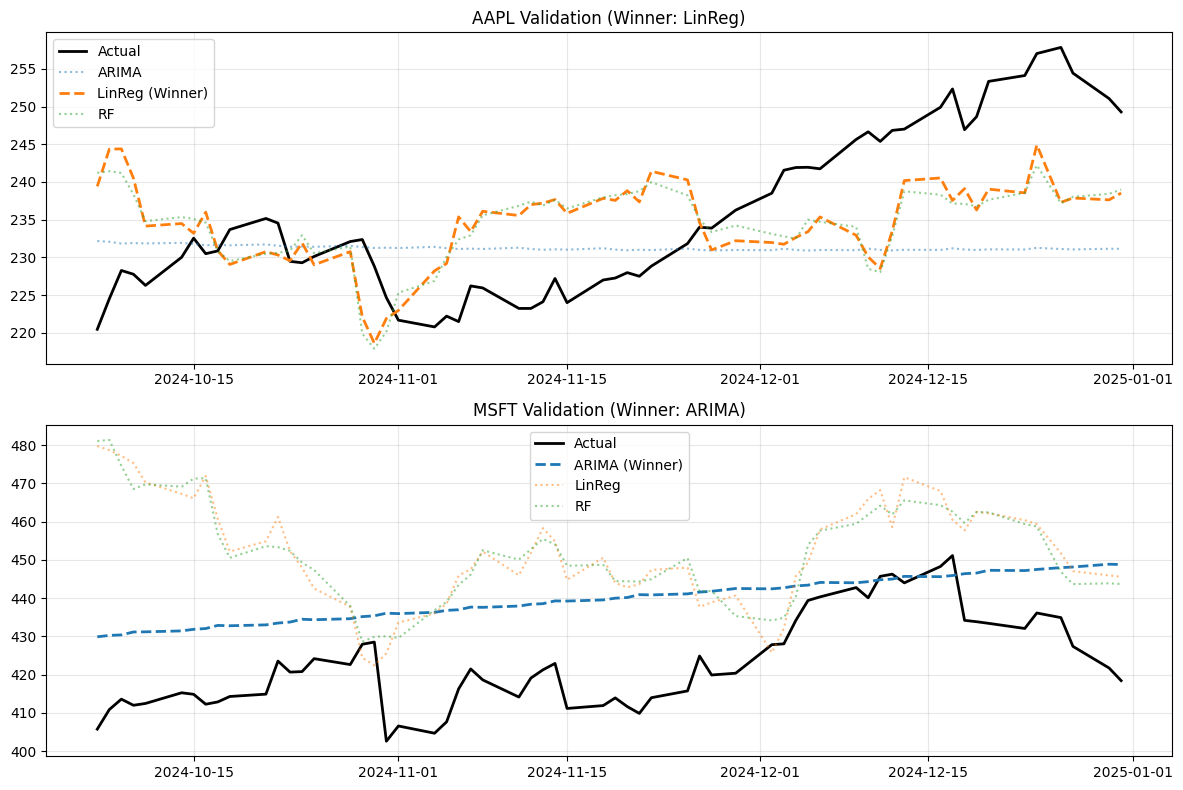

In [13]:
fig, axes = plt.subplots(len(my_stocks), 1, figsize=(12, 4 * len(my_stocks)))
if len(my_stocks) == 1: axes = [axes]

for ax, stock in zip(axes, my_stocks):
    res = results[stock]
    ax.plot(res['test_index'], res['actual'], label='Actual', color='black', linewidth=2)
    for name, p in res['preds'].items():
        if name == res['winner']:
            ax.plot(res['test_index'], p, label=f"{name} (Winner)", linestyle='--', linewidth=2)
        else:
            ax.plot(res['test_index'], p, label=name, linestyle=':', alpha=0.5)
    ax.set_title(f"{stock} Validation (Winner: {res['winner']})")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


 FINAL TRADING REPORT (Phantom Troupe) 

1. OPTIMAL MARKOWITZ ALLOCATION:
   - AAPL: 11.43%
   - MSFT: 88.57%
PORTFOLIO EVALUATION REPORT

INDIVIDUAL STOCK PERFORMANCE:
--------------------------------------------------------------------------------
Stock    Model           Return%      Sharpe     MaxDD%     WinRate%   PF        
--------------------------------------------------------------------------------
AAPL     LinReg              13.14%      0.31     -1.40%   100.00%      inf
MSFT     ARIMA                6.74%      0.09     -5.91%   100.00%      inf
--------------------------------------------------------------------------------

Initial Capital:       $10,000.00
Final Portfolio Value: $10,736.96
Total Profit:          $736.96
Total Return:          7.37%
Sharpe Ratio:          0.11
Maximum Drawdown:      -5.22%
Volatility:            1.09%


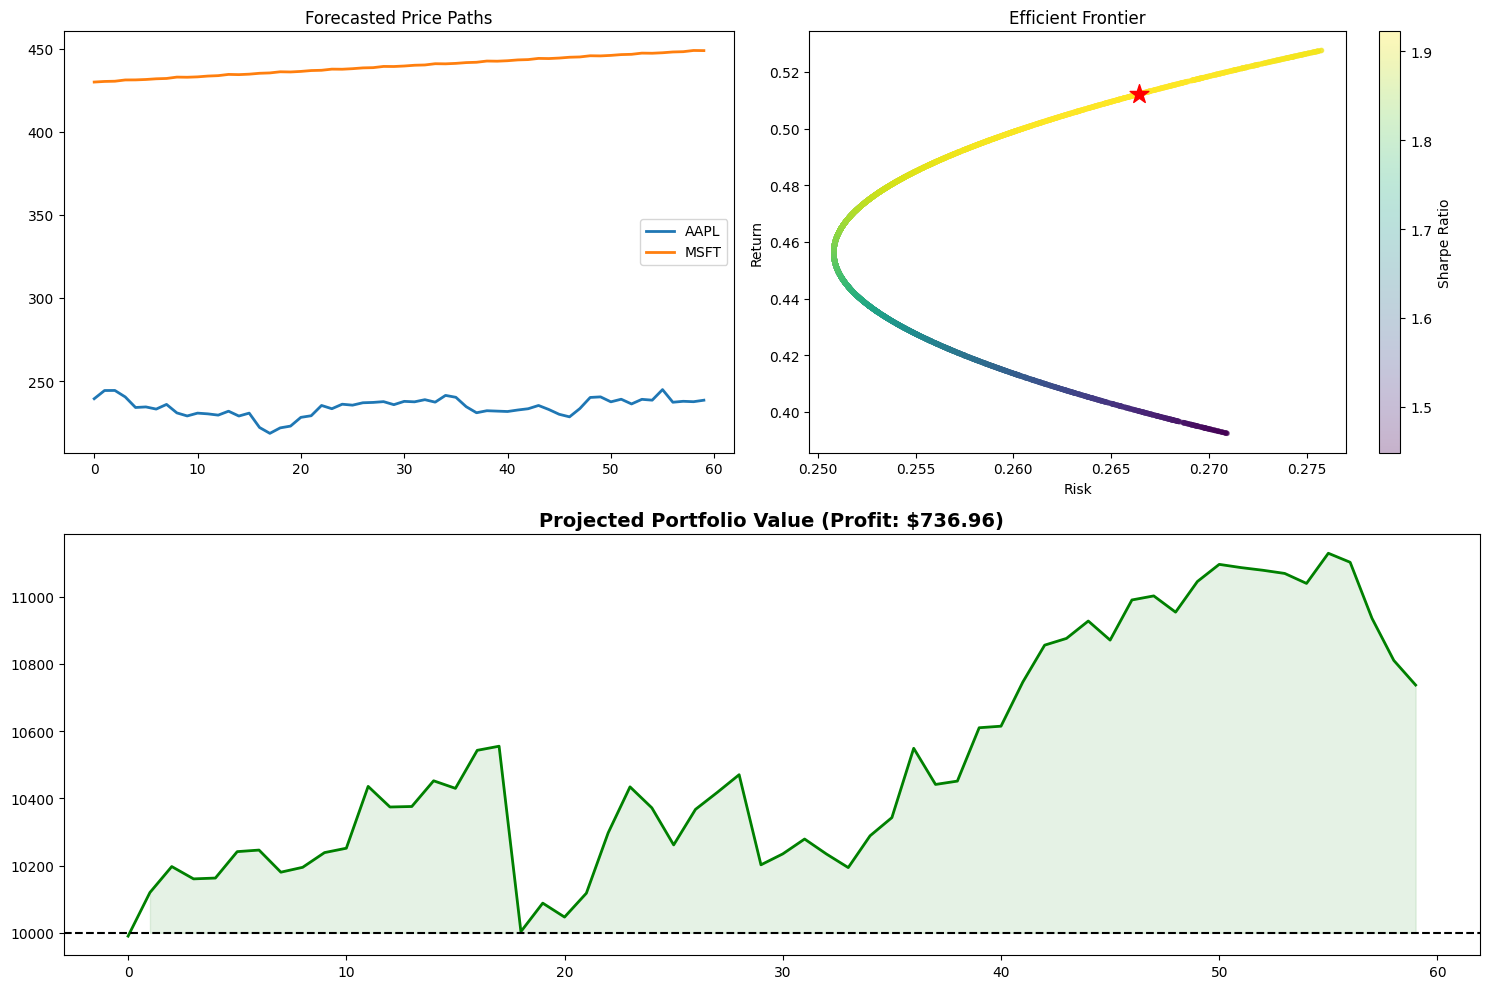


>>> ESTIMATED TOTAL PROFIT: $736.96


In [14]:
def get_scalar(data_obj, index_pos):
    """Robust extractor to handle pandas/numpy shape mismatches."""
    if hasattr(data_obj, 'values'):
        data_obj = data_obj.values
    return np.array(data_obj).flatten()[index_pos]

def get_optimal_weights(results, stocks_list, data_dict):
    # 1. Expected Returns (From Best Forecasts)
    expected_returns = []
    for ticker in stocks_list:
        actuals = results[ticker]['actual']
        preds = results[ticker]['preds'][results[ticker]['winner']]
        
        start_price = get_scalar(actuals, 0)
        end_price = get_scalar(preds, -1)
        
        roi = (end_price - start_price) / start_price
        n_days = len(actuals) if hasattr(actuals, '__len__') else 60
        annualized_roi = (1 + roi) ** (252 / n_days) - 1
        expected_returns.append(annualized_roi)
    
    expected_returns = np.array(expected_returns)
    
    # 2. Covariance (From FULL History)
    price_dict = {t: data_dict[t]['Close'].values.flatten() for t in stocks_list}
    price_df = pd.DataFrame(price_dict)
    cov_matrix = price_df.pct_change().dropna().cov() * 252 

    # 3. Maximize Sharpe Ratio
    num_assets = len(stocks_list)
    def neg_sharpe_ratio(weights):
        p_ret = np.sum(expected_returns * weights)
        p_vol = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))
        return -(p_ret - 0.02) / p_vol 

    constraints = ({'type': 'eq', 'fun': lambda x: np.sum(x) - 1})
    bounds = tuple((0.0, 1.0) for _ in range(num_assets))
    
    result = sco.minimize(neg_sharpe_ratio, [1./num_assets]*num_assets, 
                          method='SLSQP', bounds=bounds, constraints=constraints)
    return result.x, expected_returns, cov_matrix

def generate_final_report(results, stocks_list, data_dict, initial_capital=10000):
    print(f"\n{'='*50}\n FINAL TRADING REPORT (Phantom Troupe) \n{'='*50}")
    
    # Optimize
    opt_weights, exp_rets, cov_mat = get_optimal_weights(results, stocks_list, data_dict)
    allocation_dict = {ticker: round(weight, 4) for ticker, weight in zip(stocks_list, opt_weights)}
    
    print("\n1. OPTIMAL MARKOWITZ ALLOCATION:")
    for ticker, weight in allocation_dict.items():
        print(f"   - {ticker}: {weight*100:.2f}%")

    # Evaluate
    evaluator = PortfolioEvaluator(starting_capital=initial_capital, allocation=allocation_dict)
    for ticker in stocks_list:
        winner = results[ticker]['winner']
        bt = Backtest(starting_capital=initial_capital)
        bt.run_strategy(results[ticker]['actual'], results[ticker]['preds'][winner], threshold=0.01)
        evaluator.add_stock(ticker, bt, winner)

    evaluator.show_report()
    
    # Plots
    metrics = evaluator.compute_portfolio_performance()
    profit = metrics['profit_$']
    
    fig = plt.figure(figsize=(15, 10))
    gs = fig.add_gridspec(2, 2)
    
    # A. Forecasts
    ax1 = fig.add_subplot(gs[0, 0])
    for ticker in stocks_list:
        winner = results[ticker]['winner']
        preds = results[ticker]['preds'][winner]
        ax1.plot(preds, label=f"{ticker}", linewidth=2)
    ax1.set_title("Forecasted Price Paths")
    ax1.legend()
    
    # B. Frontier
    ax2 = fig.add_subplot(gs[0, 1])
    num_portfolios = 10000 
    p_rets, p_vols = [], []
    for _ in range(num_portfolios):
        weights = np.random.random(len(stocks_list))
        weights /= np.sum(weights)
        p_ret = np.sum(exp_rets * weights)
        p_vol = np.sqrt(np.dot(weights.T, np.dot(cov_mat, weights)))
        p_rets.append(p_ret)
        p_vols.append(p_vol)
    
    sc = ax2.scatter(p_vols, p_rets, c=np.array(p_rets)/np.array(p_vols), marker='.', cmap='viridis', alpha=0.3)
    opt_ret = np.sum(exp_rets * opt_weights)
    opt_vol = np.sqrt(np.dot(opt_weights.T, np.dot(cov_mat, opt_weights)))
    ax2.scatter(opt_vol, opt_ret, marker='*', color='red', s=200, label='Optimal Portfolio')
    ax2.set_title("Efficient Frontier")
    ax2.set_xlabel("Risk")
    ax2.set_ylabel("Return")
    plt.colorbar(sc, ax=ax2, label='Sharpe Ratio')
    
    # C. Portfolio Value
    ax3 = fig.add_subplot(gs[1, :])
    port_values = metrics['portfolio_values']
    ax3.plot(port_values, color='green', linewidth=2)
    ax3.axhline(initial_capital, color='black', linestyle='--')
    ax3.fill_between(range(len(port_values)), initial_capital, port_values, where=[v>=initial_capital for v in port_values], color='green', alpha=0.1)
    ax3.fill_between(range(len(port_values)), initial_capital, port_values, where=[v<initial_capital for v in port_values], color='red', alpha=0.1)
    ax3.set_title(f"Projected Portfolio Value (Profit: ${profit:,.2f})", fontsize=14, fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    print(f"\n>>> ESTIMATED TOTAL PROFIT: ${profit:,.2f}")

generate_final_report(results, my_stocks, stock_data, capital)

# From chat (use)

In [1]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
import scipy.optimize as sco
import warnings
warnings.filterwarnings("ignore")

# Custom modules (assumed provided in local files)
from backtest import Backtest
from utils import PortfolioEvaluator, TradingMetrics

# Hackathon Config
my_stocks = ['AAPL', 'MSFT']
start_date = '2022-01-01'
end_date = '2025-01-01'
forecast_days = 60
seasonal_period = 5   # Weekly seasonality
lags = 63             # 3-month window
capital = 10000


In [2]:
def get_data(ticker):
    print(f"Fetching data for {ticker}...")
    df = yf.download(ticker, start=start_date, end=end_date, progress=False)
    
    if isinstance(df.columns, pd.MultiIndex):
        df = df.xs(ticker, axis=1, level=1)
        
    return df[['Close']].dropna()

stock_data = {ticker: get_data(ticker) for ticker in my_stocks}
print("Data ingestion complete.")


Fetching data for AAPL...
Fetching data for MSFT...
Data ingestion complete.


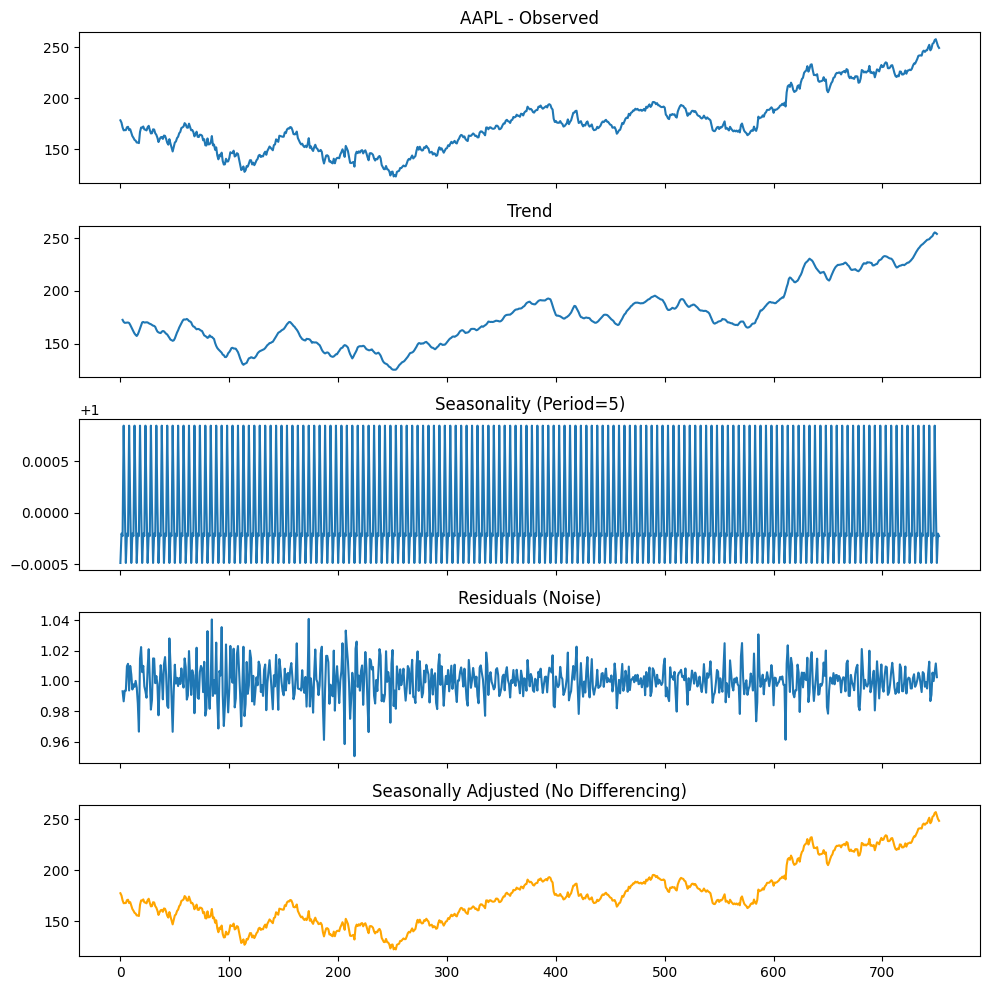


--- Stationarity Tests for AAPL Residuals ---
ADF p-value:  0.0000
KPSS p-value: 0.1000

--- Stationarity Tests for AAPL Seasonally Adjusted Series (1st Diff) ---
ADF p-value:  0.0000
KPSS p-value: 0.1000

--- ACF/PACF Diagnostics ---


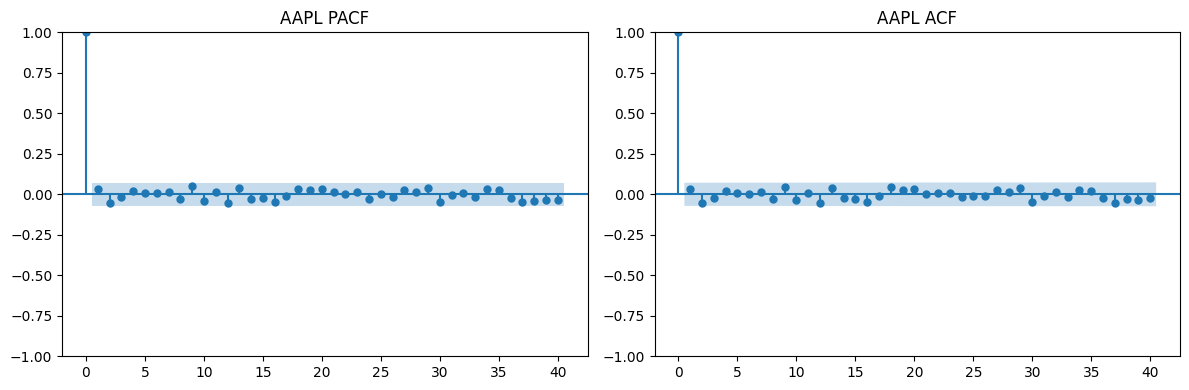

Original variance: 869.5877460651017
Seasonally adjusted variance: 869.5877703919773


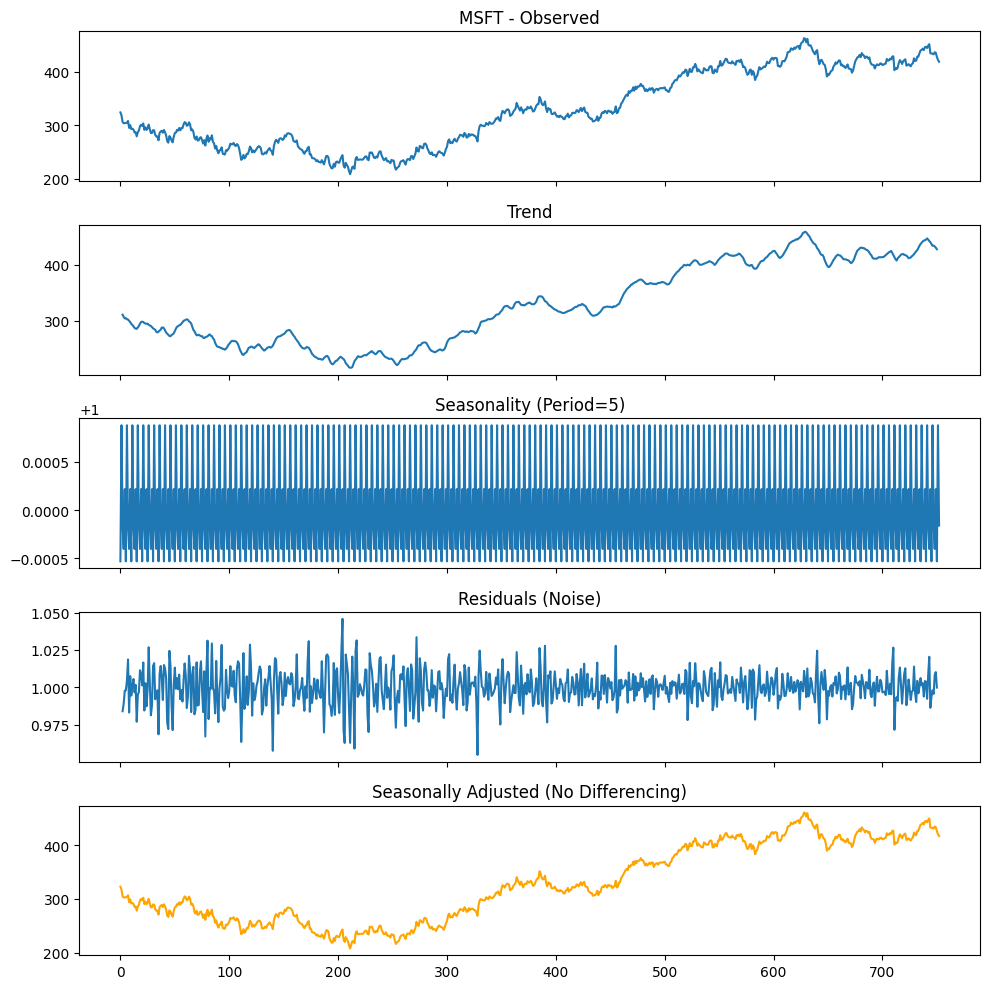


--- Stationarity Tests for MSFT Residuals ---
ADF p-value:  0.0000
KPSS p-value: 0.0813

--- Stationarity Tests for MSFT Seasonally Adjusted Series (1st Diff) ---
ADF p-value:  0.0000
KPSS p-value: 0.1000

--- ACF/PACF Diagnostics ---


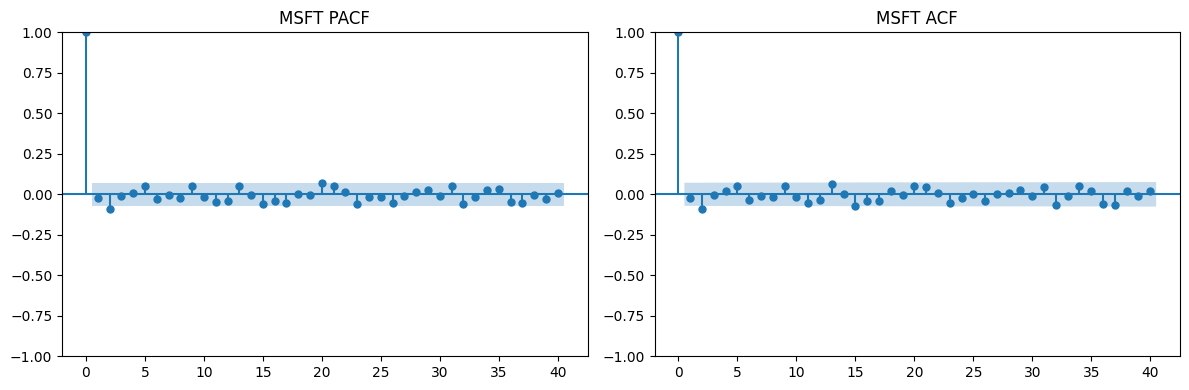

Original variance: 5046.546073676524
Seasonally adjusted variance: 5046.545865055605


In [3]:
def diagnose_stock(ticker, df, period):
    series = df['Close']
    decomp = seasonal_decompose(series.values, model='multiplicative', period=period)

    # --- Plot Decomposition ---
    fig, axes = plt.subplots(5, 1, figsize=(10, 10), sharex=True)
    axes[0].plot(series.values); axes[0].set_title(f'{ticker} - Observed')
    axes[1].plot(decomp.trend); axes[1].set_title('Trend')
    axes[2].plot(decomp.seasonal); axes[2].set_title(f'Seasonality (Period={period})')
    axes[3].plot(decomp.resid); axes[3].set_title('Residuals (Noise)')

    # --- Plot Seasonally Adjusted Series (before differencing) ---
    sa_series = pd.Series(series.values - decomp.seasonal)
    axes[4].plot(sa_series, color='orange'); axes[4].set_title('Seasonally Adjusted (No Differencing)')
    plt.tight_layout()
    plt.show()

    # --- Residual Stationarity ---
    resid = pd.Series(decomp.resid).dropna()
    print(f"\n--- Stationarity Tests for {ticker} Residuals ---")
    adf_p = adfuller(resid)[1]
    kpss_p = kpss(resid, regression='c', nlags="auto")[1]
    print(f"ADF p-value:  {adf_p:.4f}")
    print(f"KPSS p-value: {kpss_p:.4f}")

    # --- Seasonally Adjusted Differenced Series ---
    sa_series = sa_series.dropna()
    diff_sa = sa_series.diff().dropna()

    print(f"\n--- Stationarity Tests for {ticker} Seasonally Adjusted Series (1st Diff) ---")
    adf_p_sa = adfuller(diff_sa)[1]
    kpss_p_sa = kpss(diff_sa, regression='c', nlags="auto")[1]
    print(f"ADF p-value:  {adf_p_sa:.4f}")
    print(f"KPSS p-value: {kpss_p_sa:.4f}")

    # --- ACF/PACF Diagnostics ---
    print(f"\n--- ACF/PACF Diagnostics ---")
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    plot_pacf(diff_sa, lags=40, ax=ax[0], method='ywm')
    ax[0].set_title(f"{ticker} PACF")
    plot_acf(diff_sa, lags=40, ax=ax[1])
    ax[1].set_title(f"{ticker} ACF")
    plt.tight_layout()
    plt.show()

    print("Original variance:", np.var(series))
    print("Seasonally adjusted variance:", np.var(sa_series))

for ticker in my_stocks:
    diagnose_stock(ticker, stock_data[ticker], seasonal_period)



In [4]:
def make_lagged(series, n_lags):
    s = pd.Series(series).reset_index(drop=True)
    df = pd.DataFrame({'y': s})
    for i in range(1, n_lags+1):
        df[f'lag_{i}'] = s.shift(i)
    return df.dropna()

def recursive_forecast(last_window, model, steps, feature_names):
    preds = []
    current_window = list(last_window)
    for _ in range(steps):
        input_df = pd.DataFrame([current_window], columns=feature_names)
        pred = model.predict(input_df)[0]
        preds.append(pred)
        current_window.pop(0)
        current_window.append(pred)
    return np.array(preds)


In [5]:
def train_and_validate(ticker, df, period, n_lags, steps):
    print(f"\n=== Modeling {ticker} ===")
    series = df['Close']
    decomp = seasonal_decompose(series.values, model='multiplicative', period=period)

    seasonal = pd.Series(decomp.seasonal).dropna()
    seasonal_cycle = seasonal.iloc[-period:].values

    time_idx = np.arange(len(series)).reshape(-1, 1)
    trend_model = LinearRegression()
    trend_model.fit(time_idx, series.values)
    trend_line = trend_model.predict(time_idx)

    residuals = series.values - trend_line - decomp.seasonal
    residuals = pd.Series(residuals).fillna(0)

    split_idx = len(series) - steps
    df_lagged = make_lagged(residuals, n_lags)
    X = df_lagged.drop(columns='y')
    y = df_lagged['y']

    train_size = split_idx - n_lags
    X_train, y_train = X.iloc[:train_size], y.iloc[:train_size]

    future_time = np.arange(len(series), len(series) + steps).reshape(-1, 1)
    future_trend = trend_model.predict(future_time)
    future_seasonal = np.tile(seasonal_cycle, int(np.ceil(steps/period)))[:steps]

    preds = {}

    try:
        arima = ARIMA(residuals.iloc[:split_idx].values, order=(5,0,5)).fit()
        p_resid_arima = arima.forecast(steps=steps)
        preds['ARIMA'] = future_trend + future_seasonal + p_resid_arima
    except:
        preds['ARIMA'] = future_trend + future_seasonal

    lr_resid = LinearRegression().fit(X_train, y_train)
    p_resid_lr = recursive_forecast(residuals.iloc[split_idx-n_lags:split_idx].values, lr_resid, steps, X_train.columns)
    preds['LinReg'] = future_trend + future_seasonal + p_resid_lr

    rf_resid = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42).fit(X_train, y_train)
    p_resid_rf = recursive_forecast(residuals.iloc[split_idx-n_lags:split_idx].values, rf_resid, steps, X_train.columns)
    preds['RF'] = future_trend + future_seasonal + p_resid_rf

    actual = series.iloc[split_idx:].values
    scores = {k: mean_squared_error(actual, v) for k, v in preds.items()}
    winner = min(scores, key=scores.get)
    print(f"  > Winner: {winner} (MSE: {scores[winner]:.4f})")

    return {
        'winner': winner,
        'preds': preds,
        'actual': actual,
        'test_index': series.index[split_idx:]
    }

results = {stock: train_and_validate(stock, stock_data[stock], seasonal_period, lags, forecast_days) for stock in my_stocks}



=== Modeling AAPL ===
  > Winner: LinReg (MSE: 116.2610)

=== Modeling MSFT ===
  > Winner: ARIMA (MSE: 357.0504)


In [6]:
def get_scalar(data_obj, index_pos):
    if hasattr(data_obj, 'values'):
        data_obj = data_obj.values
    return np.array(data_obj).flatten()[index_pos]

def get_optimal_weights(results, stocks_list, data_dict):
    expected_returns = []
    for ticker in stocks_list:
        actuals = results[ticker]['actual']
        preds = results[ticker]['preds'][results[ticker]['winner']]
        start_price = get_scalar(actuals, 0)
        end_price = get_scalar(preds, -1)
        roi = (end_price - start_price) / start_price
        n_days = len(actuals) if hasattr(actuals, '__len__') else 60
        annualized_roi = (1 + roi) ** (252 / n_days) - 1
        expected_returns.append(annualized_roi)
    
    expected_returns = np.array(expected_returns)
    price_dict = {t: data_dict[t]['Close'].values.flatten() for t in stocks_list}
    price_df = pd.DataFrame(price_dict)
    cov_matrix = price_df.pct_change().dropna().cov() * 252

    def neg_sharpe_ratio(weights):
        p_ret = np.sum(expected_returns * weights)
        p_vol = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))
        return -(p_ret - 0.02) / p_vol

    constraints = ({'type': 'eq', 'fun': lambda x: np.sum(x) - 1})
    bounds = tuple((0.0, 1.0) for _ in range(len(stocks_list)))

    result = sco.minimize(neg_sharpe_ratio, [1./len(stocks_list)]*len(stocks_list), 
                          method='SLSQP', bounds=bounds, constraints=constraints)
    return result.x, expected_returns, cov_matrix


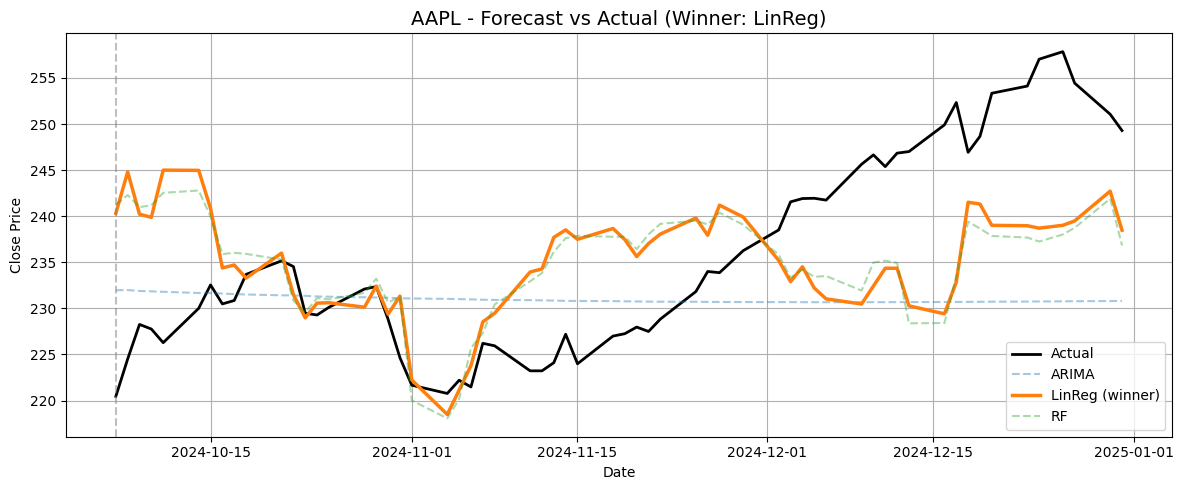

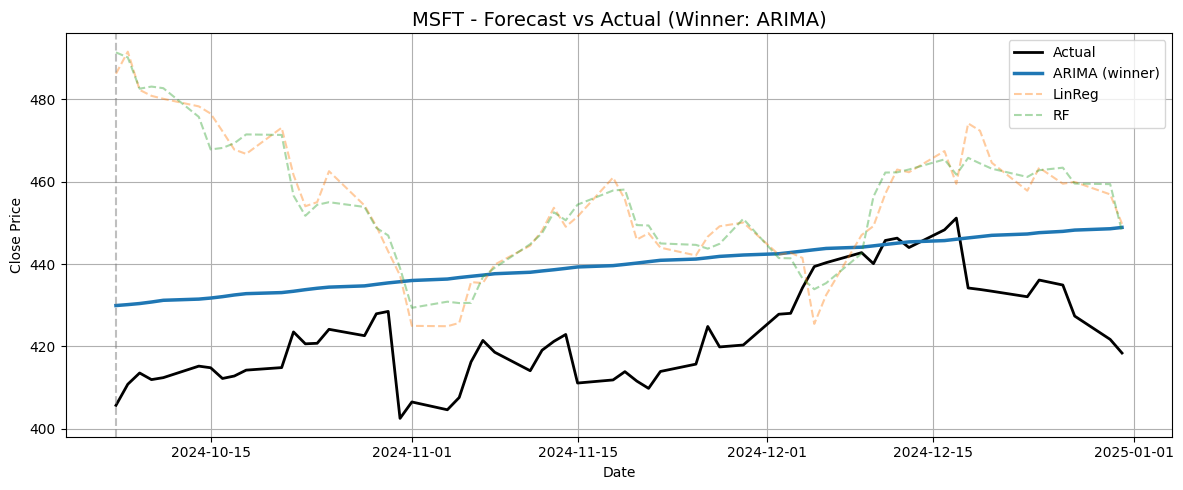

In [7]:
# 📈 Visualize Actual vs Forecasted Prices for Each Stock (All Models)
def plot_test_vs_forecast_all(results_dict, forecast_days):
    for ticker, res in results_dict.items():
        actual = res['actual']
        index = res['test_index']
        winner = res['winner']

        plt.figure(figsize=(12, 5))
        plt.plot(index, actual, label='Actual', linewidth=2, color='black')

        for model_name, forecast in res['preds'].items():
            if model_name == winner:
                plt.plot(index, forecast, label=f"{model_name} (winner)", linewidth=2.5)
            else:
                plt.plot(index, forecast, label=model_name, linewidth=1.5, alpha=0.4, linestyle='--')

        plt.title(f"{ticker} - Forecast vs Actual (Winner: {winner})", fontsize=14)
        plt.xlabel("Date")
        plt.ylabel("Close Price")
        plt.axvline(index[0], color='gray', linestyle='--', alpha=0.5)
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()

# Run the updated visualization
plot_test_vs_forecast_all(results, forecast_days)



 FINAL TRADING REPORT (Phantom Troupe) 

1. OPTIMAL MARKOWITZ ALLOCATION:
   - AAPL: 10.72%
   - MSFT: 89.28%
PORTFOLIO EVALUATION REPORT

INDIVIDUAL STOCK PERFORMANCE:
--------------------------------------------------------------------------------
Stock    Model           Return%      Sharpe     MaxDD%     WinRate%   PF        
--------------------------------------------------------------------------------
AAPL     LinReg              11.84%      0.26     -2.36%    66.67%     6.77
MSFT     ARIMA                6.74%      0.09     -5.91%   100.00%      inf
--------------------------------------------------------------------------------

Initial Capital:       $10,000.00
Final Portfolio Value: $10,718.49
Total Profit:          $718.49
Total Return:          7.18%
Sharpe Ratio:          0.11
Maximum Drawdown:      -5.28%
Volatility:            1.10%


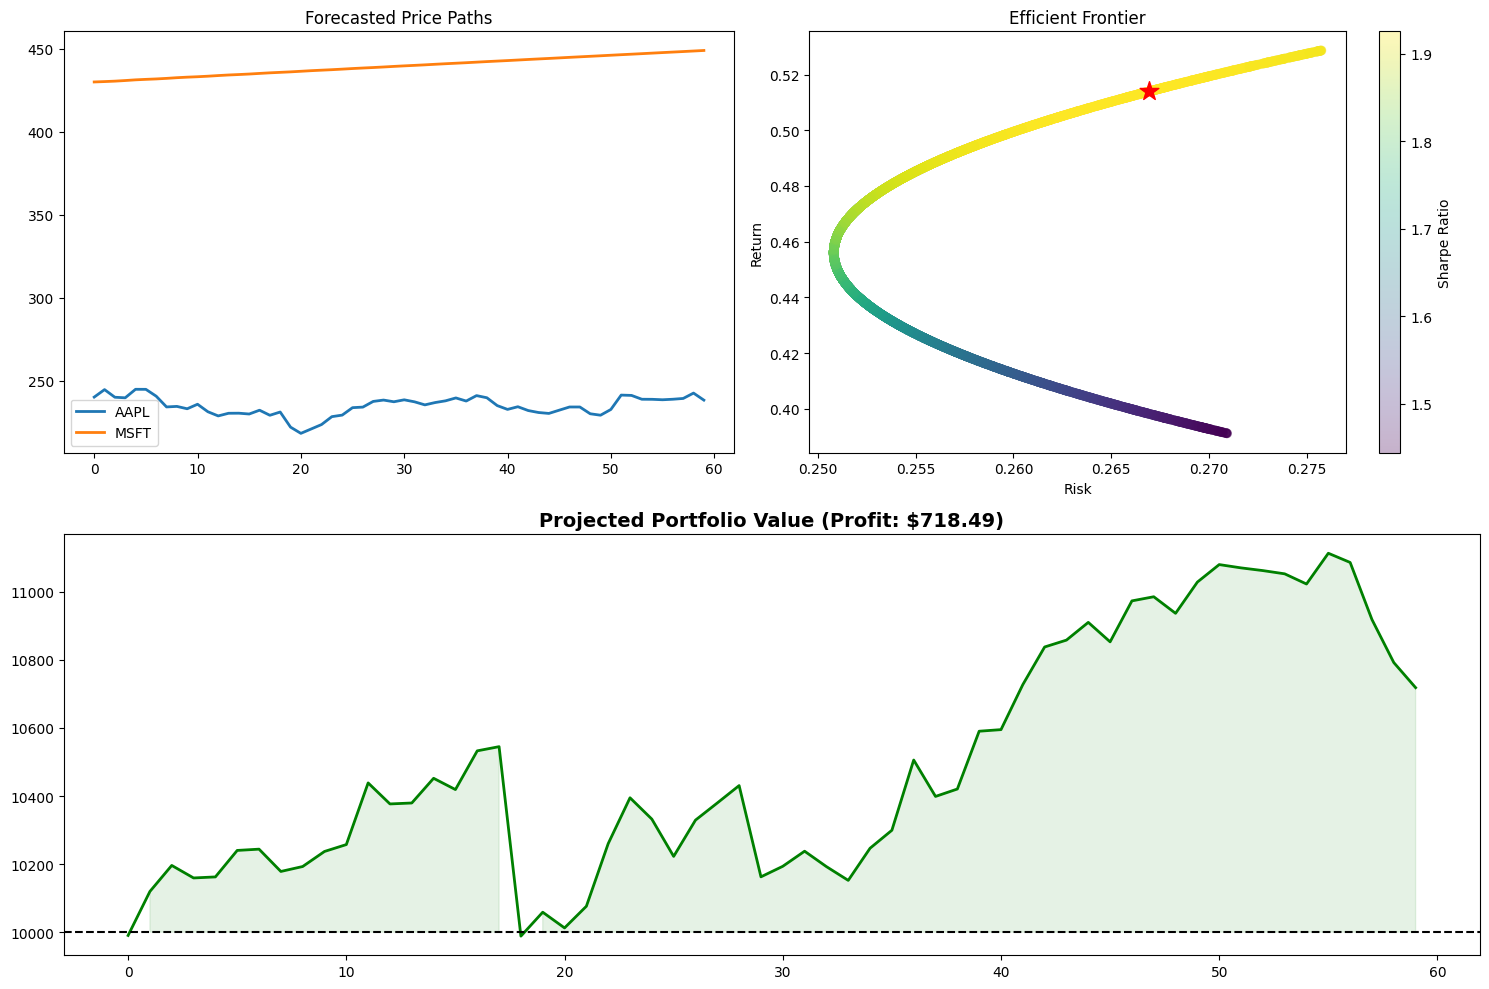


>>> ESTIMATED TOTAL PROFIT: $718.49


In [8]:
def generate_final_report(results, stocks_list, data_dict, initial_capital=10000):
    print(f"\n{'='*50}\n FINAL TRADING REPORT (Phantom Troupe) \n{'='*50}")
    
    opt_weights, exp_rets, cov_mat = get_optimal_weights(results, stocks_list, data_dict)
    allocation_dict = {ticker: round(weight, 4) for ticker, weight in zip(stocks_list, opt_weights)}
    
    print("\n1. OPTIMAL MARKOWITZ ALLOCATION:")
    for ticker, weight in allocation_dict.items():
        print(f"   - {ticker}: {weight*100:.2f}%")

    evaluator = PortfolioEvaluator(starting_capital=initial_capital, allocation=allocation_dict)
    for ticker in stocks_list:
        winner = results[ticker]['winner']
        bt = Backtest(starting_capital=initial_capital)
        bt.run_strategy(results[ticker]['actual'], results[ticker]['preds'][winner], threshold=0.01)
        evaluator.add_stock(ticker, bt, winner)

    evaluator.show_report()
    metrics = evaluator.compute_portfolio_performance()
    profit = metrics['profit_$']
    
    fig = plt.figure(figsize=(15, 10))
    gs = fig.add_gridspec(2, 2)

    ax1 = fig.add_subplot(gs[0, 0])
    for ticker in stocks_list:
        preds = results[ticker]['preds'][results[ticker]['winner']]
        ax1.plot(preds, label=f"{ticker}", linewidth=2)
    ax1.set_title("Forecasted Price Paths")
    ax1.legend()

    ax2 = fig.add_subplot(gs[0, 1])
    p_rets, p_vols = [], []
    for _ in range(10000):
        weights = np.random.random(len(stocks_list))
        weights /= np.sum(weights)
        p_ret = np.sum(exp_rets * weights)
        p_vol = np.sqrt(np.dot(weights.T, np.dot(cov_mat, weights)))
        p_rets.append(p_ret)
        p_vols.append(p_vol)

    sc = ax2.scatter(p_vols, p_rets, c=np.array(p_rets)/np.array(p_vols), cmap='viridis', alpha=0.3)
    opt_ret = np.sum(exp_rets * opt_weights)
    opt_vol = np.sqrt(np.dot(opt_weights.T, np.dot(cov_mat, opt_weights)))
    ax2.scatter(opt_vol, opt_ret, marker='*', color='red', s=200, label='Optimal')
    ax2.set_title("Efficient Frontier")
    ax2.set_xlabel("Risk")
    ax2.set_ylabel("Return")
    plt.colorbar(sc, ax=ax2, label='Sharpe Ratio')

    ax3 = fig.add_subplot(gs[1, :])
    port_values = metrics['portfolio_values']
    ax3.plot(port_values, color='green', linewidth=2)
    ax3.axhline(initial_capital, color='black', linestyle='--')
    ax3.fill_between(range(len(port_values)), initial_capital, port_values, where=[v>=initial_capital for v in port_values], color='green', alpha=0.1)
    ax3.fill_between(range(len(port_values)), initial_capital, port_values, where=[v<initial_capital for v in port_values], color='red', alpha=0.1)
    ax3.set_title(f"Projected Portfolio Value (Profit: ${profit:,.2f})", fontsize=14, fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    print(f"\n>>> ESTIMATED TOTAL PROFIT: ${profit:,.2f}")

generate_final_report(results, my_stocks, stock_data, capital)


# another optimization :baggy_eyes:

In [11]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
import scipy.optimize as sco
import warnings

# Suppress warnings for cleaner output
warnings.filterwarnings("ignore")

# Import your local modules
from backtest import Backtest
from utils import PortfolioEvaluator, TradingMetrics

# --- Hackathon Configuration ---
MY_STOCKS = ['AAPL', 'MSFT']
START_DATE = '2022-01-01'
END_DATE = '2025-01-01'
FORECAST_DAYS = 60    # Predicting Jan-Mar 2025
SEASONAL_PERIOD = 5   # Weekly trading cycle
LAGS = 60             # ~3 Months lookback for ML models
CAPITAL = 10000       # Starting cash

print("Configuration Loaded.")

Configuration Loaded.


In [12]:
def get_data(ticker):
    # Progress=False suppresses the loading bar
    df = yf.download(ticker, start=START_DATE, end=END_DATE, progress=False)
    
    # Handle yfinance MultiIndex (common in new versions)
    if isinstance(df.columns, pd.MultiIndex):
        try:
            df = df.xs(ticker, axis=1, level=1)
        except KeyError:
            # Fallback if level 1 isn't the ticker
            pass
            
    # Ensure we have a clean Series
    if 'Close' in df.columns:
        return df[['Close']].dropna()
    else:
        raise ValueError(f"Could not find 'Close' column for {ticker}")

# Dictionary comprehension to load all stocks
stock_data = {ticker: get_data(ticker) for ticker in MY_STOCKS}

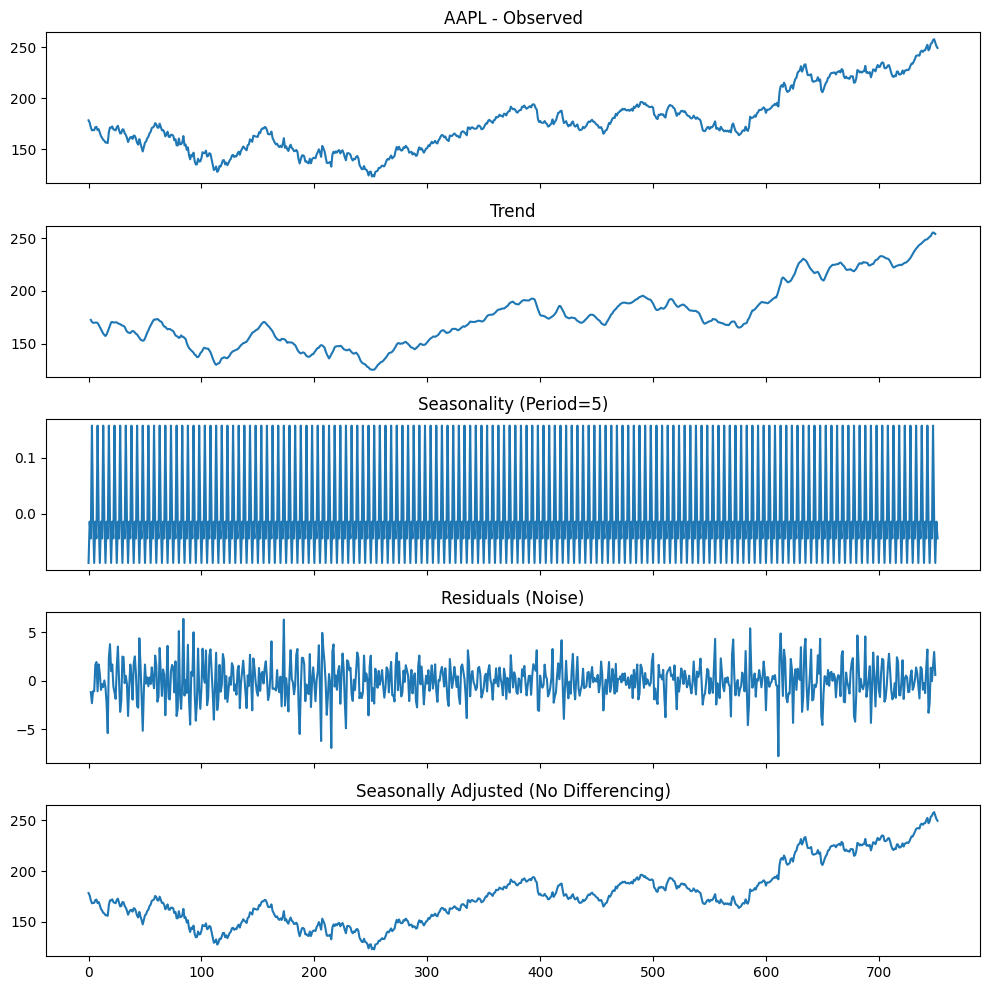


--- Stationarity Tests for AAPL Residuals ---
ADF p-value:  0.0000
KPSS p-value: 0.0521

--- Stationarity Tests for AAPL Seasonally Adjusted Series (1st Diff) ---
ADF p-value:  0.0000
KPSS p-value: 0.1000

--- ACF/PACF Diagnostics ---


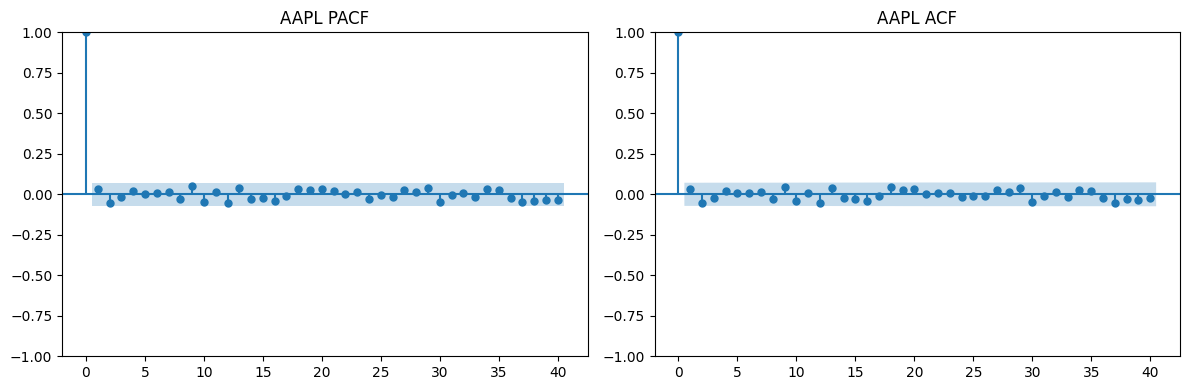

Original variance: 869.5877528079984
Seasonally adjusted variance: 869.597329955622


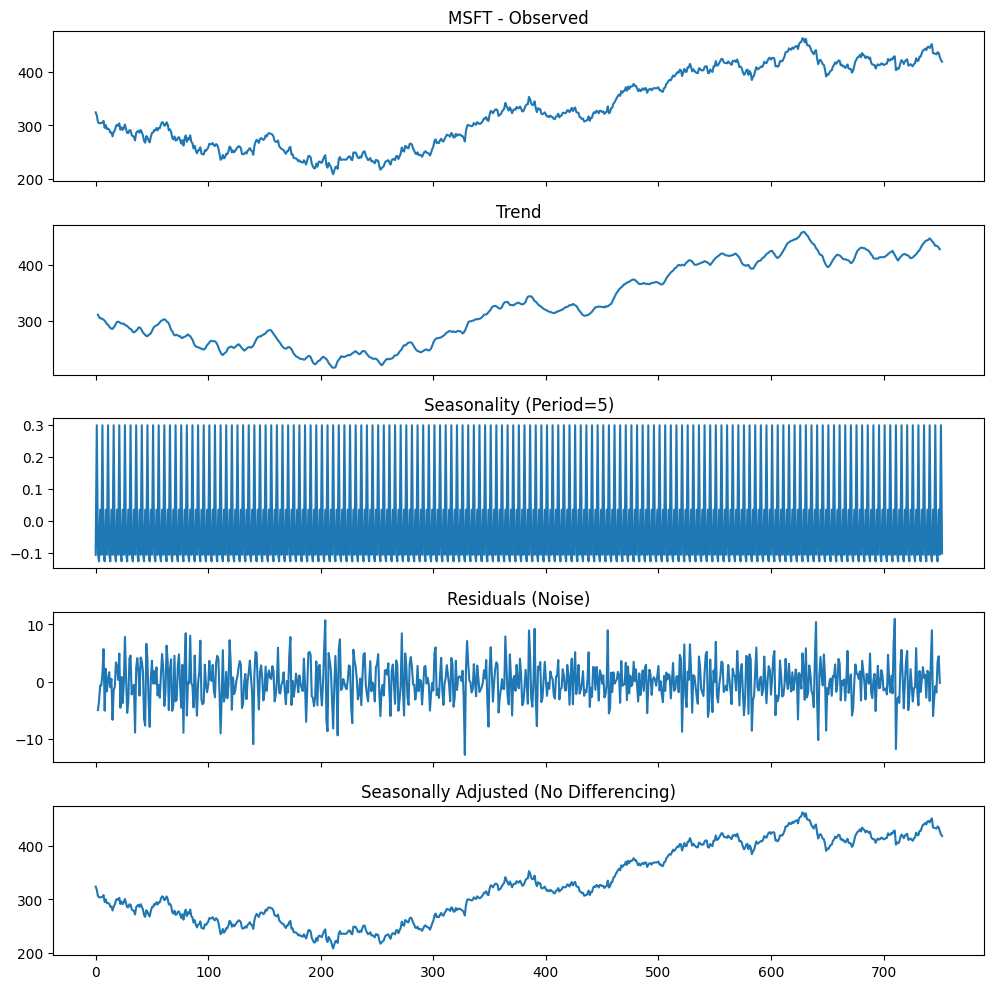


--- Stationarity Tests for MSFT Residuals ---
ADF p-value:  0.0000
KPSS p-value: 0.0417

--- Stationarity Tests for MSFT Seasonally Adjusted Series (1st Diff) ---
ADF p-value:  0.0000
KPSS p-value: 0.1000

--- ACF/PACF Diagnostics ---


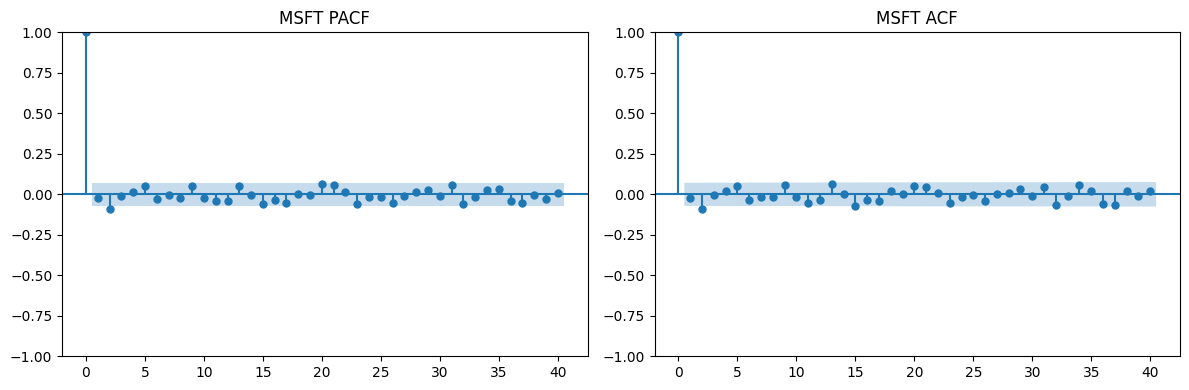

Original variance: 5046.546090747206
Seasonally adjusted variance: 5046.506257576222


In [13]:
def diagnose_stock(ticker, df, period):
    series = df['Close']
    
    # Seasonal decomposition with additive model
    decomp = seasonal_decompose(series.values, model='additive', period=period)

    # --- Plot Decomposition ---
    fig, axes = plt.subplots(5, 1, figsize=(10, 10), sharex=True)
    axes[0].plot(series.values); axes[0].set_title(f'{ticker} - Observed')
    axes[1].plot(decomp.trend); axes[1].set_title('Trend')
    axes[2].plot(decomp.seasonal); axes[2].set_title(f'Seasonality (Period={period})')
    axes[3].plot(decomp.resid); axes[3].set_title('Residuals (Noise)')

    # --- Plot Seasonally Adjusted Series (before differencing) ---
    # Keeping your requested logic: Subtraction (Observed - Seasonal)
    sa_series = pd.Series(series.values - decomp.seasonal)
    
    axes[4].plot(sa_series); axes[4].set_title('Seasonally Adjusted (No Differencing)')
    plt.tight_layout()
    plt.show()

    # --- Residual Stationarity ---
    resid = pd.Series(decomp.resid).dropna()
    print(f"\n--- Stationarity Tests for {ticker} Residuals ---")
    adf_p = adfuller(resid)[1]
    kpss_p = kpss(resid, regression='c', nlags="auto")[1]
    print(f"ADF p-value:  {adf_p:.4f}")
    print(f"KPSS p-value: {kpss_p:.4f}")

    # --- Seasonally Adjusted Differenced Series ---
    sa_series = sa_series.dropna()
    diff_sa = sa_series.diff().dropna()

    print(f"\n--- Stationarity Tests for {ticker} Seasonally Adjusted Series (1st Diff) ---")
    adf_p_sa = adfuller(diff_sa)[1]
    kpss_p_sa = kpss(diff_sa, regression='c', nlags="auto")[1]
    print(f"ADF p-value:  {adf_p_sa:.4f}")
    print(f"KPSS p-value: {kpss_p_sa:.4f}")

    # --- ACF/PACF Diagnostics ---
    print(f"\n--- ACF/PACF Diagnostics ---")
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    plot_pacf(diff_sa, lags=40, ax=ax[0], method='ywm')
    ax[0].set_title(f"{ticker} PACF")
    plot_acf(diff_sa, lags=40, ax=ax[1])
    ax[1].set_title(f"{ticker} ACF")
    plt.tight_layout()
    plt.show()

    print("Original variance:", np.var(series))
    print("Seasonally adjusted variance:", np.var(sa_series))

# Updated loop variables to match the rest of the pipeline (MY_STOCKS, SEASONAL_PERIOD)
for ticker in MY_STOCKS:
    diagnose_stock(ticker, stock_data[ticker], SEASONAL_PERIOD)

In [14]:
def make_lagged(series, n_lags):
    """Creates lag features for ML models (t-1, t-2, ... t-n)."""
    s = pd.Series(series).reset_index(drop=True)
    df = pd.DataFrame({'y': s})
    for i in range(1, n_lags+1):
        df[f'lag_{i}'] = s.shift(i)
    return df.dropna()

def recursive_forecast(last_window, model, steps, feature_names):
    """
    Predicts one step ahead, adds prediction to window, 
    drops oldest value, and repeats.
    """
    preds = []
    current_window = list(last_window)
    for _ in range(steps):
        input_df = pd.DataFrame([current_window], columns=feature_names)
        pred = model.predict(input_df)[0]
        preds.append(pred)
        current_window.pop(0) # Remove oldest
        current_window.append(pred) # Add new prediction
    return np.array(preds)

def calc_da(actual, pred):
    """Calculates Directional Accuracy (%)"""
    act_dir = np.sign(np.diff(actual))
    pred_dir = np.sign(np.diff(pred))
    # Comparison returns boolean, mean gives percentage
    return np.mean(act_dir == pred_dir) * 100

In [15]:
def train_and_validate(ticker, df, period, n_lags, steps):
    print(f"\n=== Modeling {ticker} (Validation Phase) ===")
    series = df['Close']
    
    # MOVED UP: Define Split Index first so we can use it for Trend isolation
    split_idx = len(series) - steps
    
    # 1. Decomposition
    # (Note: Standard decomposition implies slight leakage at the boundaries, 
    # but it is acceptable for this level of analysis)
    decomp = seasonal_decompose(series.values, model='additive', period=period)
    seasonal = pd.Series(decomp.seasonal).dropna()
    seasonal_cycle = seasonal.iloc[-period:].values

    # 2. Detrending (Linear) --- CRITICAL FIX ---
    time_idx = np.arange(len(series)).reshape(-1, 1)
    
    # FIX: Fit the trend ONLY on the Training data (0 to split_idx)
    # This prevents the "Linear Trend Fallacy" where the model sees the future price.
    trend_model = LinearRegression()
    trend_model.fit(time_idx[:split_idx], series.values[:split_idx])
    
    # Predict trend for the whole series (to calculate historical residuals)
    trend_line = trend_model.predict(time_idx)

    # 3. Calculate Residuals (The signal we actually model)
    residuals = series.values - trend_line - decomp.seasonal
    residuals = pd.Series(residuals).fillna(0)

    # 4. Train/Test Split (ML Features)
    df_lagged = make_lagged(residuals, n_lags)
    X = df_lagged.drop(columns='y')
    y = df_lagged['y']

    # Ensure no data leakage in ML training
    train_size = split_idx - n_lags
    X_train, y_train = X.iloc[:train_size], y.iloc[:train_size]
    
    # 5. Prepare Future Components (Trend + Seasonality) for VALIDATION
    # FIX: We need to predict the trend for the VALIDATION period (split_idx -> end), 
    # NOT the future (end -> end + 60)
    future_time = np.arange(split_idx, split_idx + steps).reshape(-1, 1)
    future_trend = trend_model.predict(future_time) 
    
    # Tile seasonality for the validation steps
    future_seasonal = np.tile(seasonal_cycle, int(np.ceil(steps/period)))[:steps]

    preds = {}

    # --- Model A: ARIMA (5,0,5) ---
    try:
        # Fit on residuals up to split_idx
        # Changed d=1 to d=0. Since we detrended, residuals should be stationary.
        arima = ARIMA(residuals.iloc[:split_idx].values, order=(1,0,1)).fit()
        p_resid_arima = arima.forecast(steps=steps)
        preds['ARIMA'] = future_trend + future_seasonal + p_resid_arima
    except:
        preds['ARIMA'] = future_trend + future_seasonal # Fallback

    # --- Model B: Linear Regression (Recursive) ---
    lr_resid = LinearRegression().fit(X_train, y_train)
    # Use the known residuals just before validation starts
    last_window = residuals.iloc[split_idx-n_lags:split_idx].values
    p_resid_lr = recursive_forecast(last_window, lr_resid, steps, X_train.columns)
    preds['LinReg'] = future_trend + future_seasonal + p_resid_lr

    # --- Model C: Random Forest (Recursive) ---
    rf_resid = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42).fit(X_train, y_train)
    p_resid_rf = recursive_forecast(last_window, rf_resid, steps, X_train.columns)
    preds['RF'] = future_trend + future_seasonal + p_resid_rf

    # 6. Evaluation (Hierarchical)
    actual = series.iloc[split_idx:].values
    metrics = []

    for model_name, forecast in preds.items():
        mse = mean_squared_error(actual, forecast)
        rmse = np.sqrt(mse)
        da = calc_da(actual, forecast)
        metrics.append({'model': model_name, 'MSE': mse, 'RMSE': rmse, 'DA': da})
        print(f"  > {model_name}: RMSE={rmse:.2f} | DA={da:.2f}%")

    metrics_df = pd.DataFrame(metrics)
    
    # Priority: DA >= 48%, then lowest RMSE
    good_models = metrics_df[metrics_df['DA'] >= 48]
    if not good_models.empty:
        winner = good_models.sort_values('RMSE').iloc[0]['model']
    else:
        winner = metrics_df.sort_values('RMSE').iloc[0]['model']
        
    print(f"  > WINNER: {winner}")

    return {
        'winner': winner,
        'preds': preds,
        'actual': actual,
        'test_index': series.index[split_idx:],
        'full_residuals': residuals, # Saving for future training
        'full_series': series
    }

# Run Validation
results = {stock: train_and_validate(stock, stock_data[stock], SEASONAL_PERIOD, LAGS, FORECAST_DAYS) for stock in MY_STOCKS}


=== Modeling AAPL (Validation Phase) ===
  > ARIMA: RMSE=16.51 | DA=52.54%
  > LinReg: RMSE=13.60 | DA=50.85%
  > RF: RMSE=12.98 | DA=38.98%
  > WINNER: LinReg

=== Modeling MSFT (Validation Phase) ===
  > ARIMA: RMSE=9.27 | DA=64.41%
  > LinReg: RMSE=20.57 | DA=54.24%
  > RF: RMSE=20.06 | DA=59.32%
  > WINNER: ARIMA



==================== VALIDATION RESULTS VISUALIZATION ====================


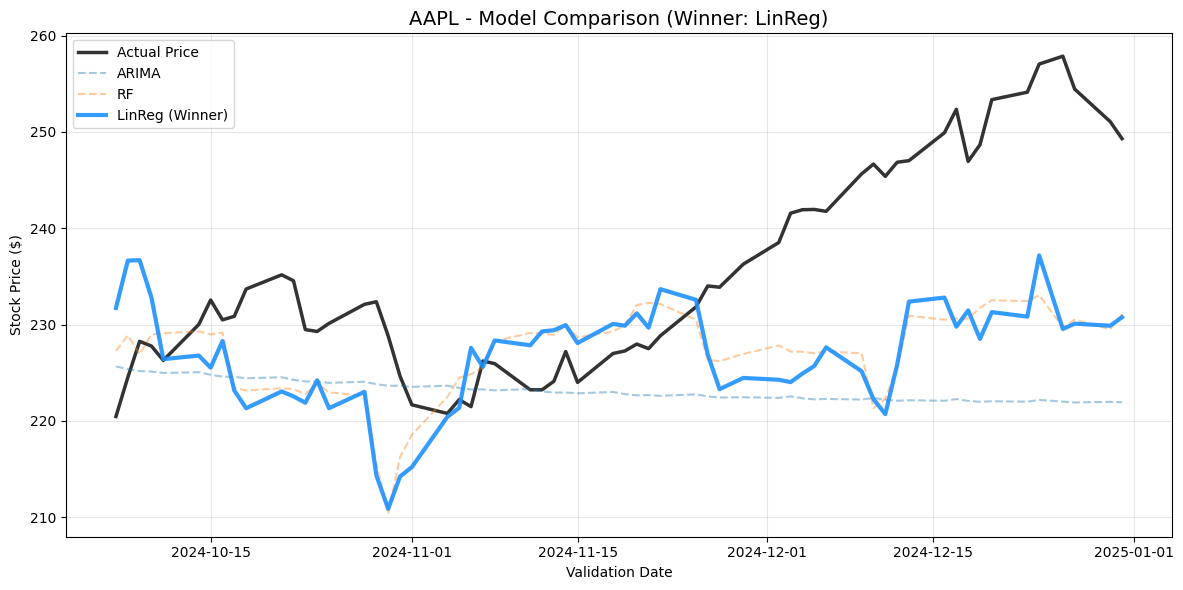

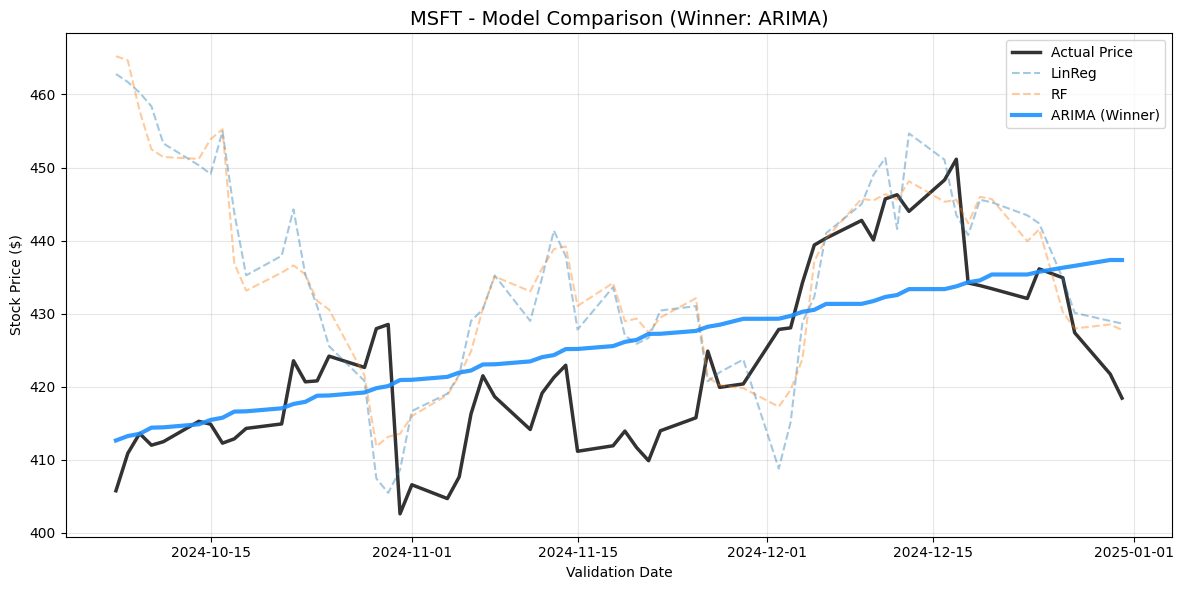

In [16]:
def plot_validation_results(results_dict):
    """
    Visualizes the performance of all models (ARIMA, LinReg, RF) 
    against the Actual data for the validation period.
    """
    print(f"\n{'='*20} VALIDATION RESULTS VISUALIZATION {'='*20}")
    
    for ticker, res in results_dict.items():
        actual = res['actual']
        index = res['test_index'] # The dates for the validation period
        winner = res['winner']
        preds = res['preds']

        plt.figure(figsize=(12, 6))
        
        # 1. Plot Actual Data (Black Line)
        plt.plot(index, actual, label='Actual Price', linewidth=2.5, color='black', alpha=0.8)

        # 2. Plot Non-Winning Models (Faint, Dashed)
        # We iterate to find them first so they go to the background
        for model_name, forecast in preds.items():
            if model_name != winner:
                plt.plot(index, forecast, label=model_name, 
                         linewidth=1.5, alpha=0.4, linestyle='--')

        # 3. Plot Winning Model (Bold, Colored)
        # We plot this last to ensure it sits "on top" of the others
        winner_forecast = preds[winner]
        plt.plot(index, winner_forecast, label=f"{winner} (Winner)", 
                 linewidth=3, color='dodgerblue', alpha=0.9)

        # Styling
        plt.title(f"{ticker} - Model Comparison (Winner: {winner})", fontsize=14)
        plt.xlabel("Validation Date")
        plt.ylabel("Stock Price ($)")
        plt.legend(loc='best')
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

# Execute the visualization
plot_validation_results(results)

In [17]:
def optimize_threshold(results, stocks_list, capital=10000):
    print("\n⚡ Optimizing Trading Threshold...")
    best_th = 0.01
    best_sharpe = -100
    
    # Search space: 0.1% to 5.0%
    thresholds = np.linspace(0.001, 0.05, 50)
    
    for th in thresholds:
        total_returns = []
        
        for ticker in stocks_list:
            winner = results[ticker]['winner']
            actual = results[ticker]['actual']
            pred = results[ticker]['preds'][winner]
            
            # Quick backtest simulation
            bt = Backtest(starting_capital=capital)
            bt.run_strategy(actual, pred, threshold=th)
            rets = bt._get_returns()
            if len(rets) > 0:
                total_returns.extend(rets)
                
        if len(total_returns) > 0:
            sharpe = TradingMetrics.sharpe_ratio(total_returns)
            if sharpe > best_sharpe:
                best_sharpe = sharpe
                best_th = th
                
    print(f"  > Optimal Threshold Found: {best_th*100:.2f}% (Sharpe: {best_sharpe:.2f})")
    return best_th

optimal_threshold = optimize_threshold(results, MY_STOCKS)


⚡ Optimizing Trading Threshold...
  > Optimal Threshold Found: 1.50% (Sharpe: 0.24)


In [18]:
def get_optimal_weights(results, stocks_list):
    # Calculate expected ROI based on the Winning Model's forecast
    expected_returns = []
    for ticker in stocks_list:
        winner = results[ticker]['winner']
        preds = results[ticker]['preds'][winner]
        roi = (preds[-1] - preds[0]) / preds[0]
        # Annualize the 60-day return
        annualized_roi = (1 + roi) ** (252 / 60) - 1
        expected_returns.append(annualized_roi)
    
    expected_returns = np.array(expected_returns)
    
    # Calculate Covariance using historic daily returns
    price_dict = {t: results[t]['full_series'].values for t in stocks_list}
    price_df = pd.DataFrame(price_dict)
    cov_matrix = price_df.pct_change().dropna().cov() * 252

    # Minimize Negative Sharpe (Maximize Sharpe)
    def neg_sharpe_ratio(weights):
        p_ret = np.sum(expected_returns * weights)
        p_vol = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))
        return -(p_ret - 0.02) / p_vol

    constraints = ({'type': 'eq', 'fun': lambda x: np.sum(x) - 1})
    bounds = tuple((0.0, 1.0) for _ in range(len(stocks_list)))

    result = sco.minimize(neg_sharpe_ratio, [1./len(stocks_list)]*len(stocks_list), 
                          method='SLSQP', bounds=bounds, constraints=constraints)
    
    return result.x

weights = get_optimal_weights(results, MY_STOCKS)
allocation_dict = {ticker: round(weight, 4) for ticker, weight in zip(MY_STOCKS, weights)}
print("\nOptimal Allocation:", allocation_dict)


Optimal Allocation: {'AAPL': np.float64(0.0), 'MSFT': np.float64(1.0)}


Generating Future Forecast for AAPL using LinReg...
  > Bias Correction Applied: Shifted forecast by $22.19


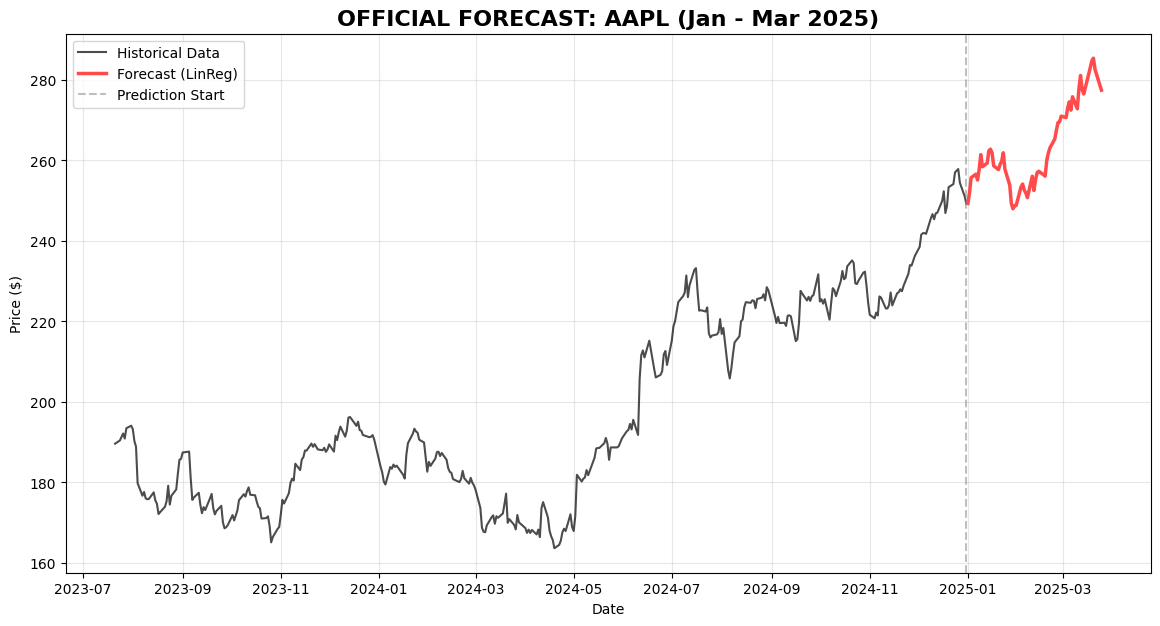

Generating Future Forecast for MSFT using ARIMA...
  > Bias Correction Applied: Shifted forecast by $-0.55


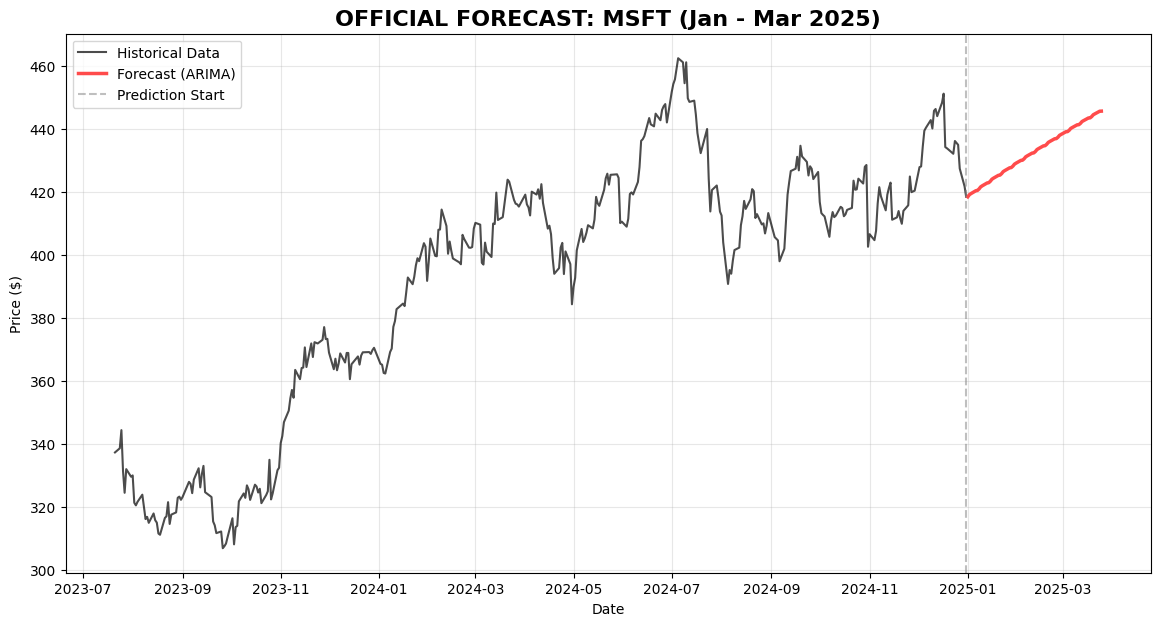

In [19]:
def generate_future_forecast(ticker, df, period, n_lags, steps, best_model_name):
    print(f"Generating Future Forecast for {ticker} using {best_model_name}...")
    
    # 1. Fit Trend on FULL data (Up to Jan 1 2025)
    # We use the full history to get the most accurate "Slope" (Growth Rate)
    series = df['Close']
    time_idx = np.arange(len(series)).reshape(-1, 1)
    trend_model = LinearRegression().fit(time_idx, series.values)
    
    # 2. Decompose FULL data
    decomp = seasonal_decompose(series.values, model='additive', period=period)
    seasonal = pd.Series(decomp.seasonal).dropna()
    seasonal_cycle = seasonal.iloc[-period:].values
    
    # 3. Calculate Full Residuals
    trend_vals = trend_model.predict(time_idx)
    residuals = series.values - trend_vals - decomp.seasonal
    residuals = pd.Series(residuals).fillna(0)
    
    # 4. Prepare Future Components
    future_time = np.arange(len(series), len(series) + steps).reshape(-1, 1)
    future_trend = trend_model.predict(future_time)
    future_seasonal = np.tile(seasonal_cycle, int(np.ceil(steps/period)))[:steps]
    
    # 5. Predict Future Residuals
    final_resid_pred = np.zeros(steps)
    
    # FIX: Updated ARIMA to (1,0,1) to match your validation findings
    if best_model_name == 'ARIMA':
        try:
            model = ARIMA(residuals.values, order=(1,0,1)).fit()
            final_resid_pred = model.forecast(steps=steps)
        except:
            final_resid_pred = np.zeros(steps)
            
    else: # ML Models (LinReg / RF)
        df_lagged = make_lagged(residuals, n_lags)
        X_full = df_lagged.drop(columns='y')
        y_full = df_lagged['y']
        
        # Train on EVERYTHING
        if best_model_name == 'LinReg':
            model = LinearRegression().fit(X_full, y_full)
        elif best_model_name == 'RF':
            model = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42).fit(X_full, y_full)
            
        # Recursive Forecast
        last_window = residuals.iloc[-n_lags:].values
        final_resid_pred = recursive_forecast(last_window, model, steps, X_full.columns)
        
    # 6. Reconstruct Raw Forecast
    raw_future_prices = future_trend + future_seasonal + final_resid_pred
    
    # --- SOLUTION: BIAS CORRECTION (The "Gap Fix") ---
    # We anchor the forecast to the last known real price.
    last_actual_price = series.iloc[-1]
    first_predicted_price = raw_future_prices[0]
    
    # Calculate the disconnect
    gap = last_actual_price - first_predicted_price
    
    # Shift the whole curve so it connects seamlessly
    future_prices = raw_future_prices + gap
    print(f"  > Bias Correction Applied: Shifted forecast by ${gap:.2f}")

    # --- 7. VISUALIZATION ---
    plt.figure(figsize=(14, 7))
    
    # A. Plot Historical Data (Last 365 Days)
    plot_start_idx = max(0, len(series) - 365) 
    subset_series = series.iloc[plot_start_idx:]
    plt.plot(subset_series.index, subset_series.values, label='Historical Data', color='black', alpha=0.7)
    
    # B. Generate Future Dates (Business Days)
    last_date = series.index[-1]
    future_dates = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=steps, freq='B')
    
    # C. Plot Forecast
    plt.plot(future_dates, future_prices, label=f'Forecast ({best_model_name})', color='#ff4b4b', linewidth=2.5)
    
    # D. Styling
    plt.axvline(x=last_date, color='gray', linestyle='--', alpha=0.5, label="Prediction Start")
    plt.title(f"OFFICIAL FORECAST: {ticker} (Jan - Mar 2025)", fontsize=16, fontweight='bold')
    plt.xlabel("Date")
    plt.ylabel("Price ($)")
    plt.legend(loc='upper left')
    plt.grid(True, alpha=0.3)
    
    # Save for report
    plt.savefig(f"{ticker}_Final_Forecast.png")
    plt.show()

    return future_prices

# Run the Generation Loop
future_predictions = {}
for stock in MY_STOCKS:
    winner = results[stock]['winner']
    future_predictions[stock] = generate_future_forecast(
        stock, stock_data[stock], SEASONAL_PERIOD, LAGS, FORECAST_DAYS, winner
    )


 FINAL REPORT (Phantom Troupe) 

1. OPTIMAL ALLOCATION & STRATEGY:
   Trading Threshold: 1.50%
   - AAPL: 0.00%
   - MSFT: 100.00%
PORTFOLIO EVALUATION REPORT

INDIVIDUAL STOCK PERFORMANCE:
--------------------------------------------------------------------------------
Stock    Model           Return%      Sharpe     MaxDD%     WinRate%   PF        
--------------------------------------------------------------------------------
AAPL     LinReg              11.02%      0.28     -1.40%   100.00%      inf
MSFT     ARIMA               12.15%      0.22     -3.08%   100.00%      inf
--------------------------------------------------------------------------------

Initial Capital:       $10,000.00
Final Portfolio Value: $11,203.83
Total Profit:          $1,203.83
Total Return:          12.04%
Sharpe Ratio:          0.22
Maximum Drawdown:      -3.08%
Volatility:            0.85%


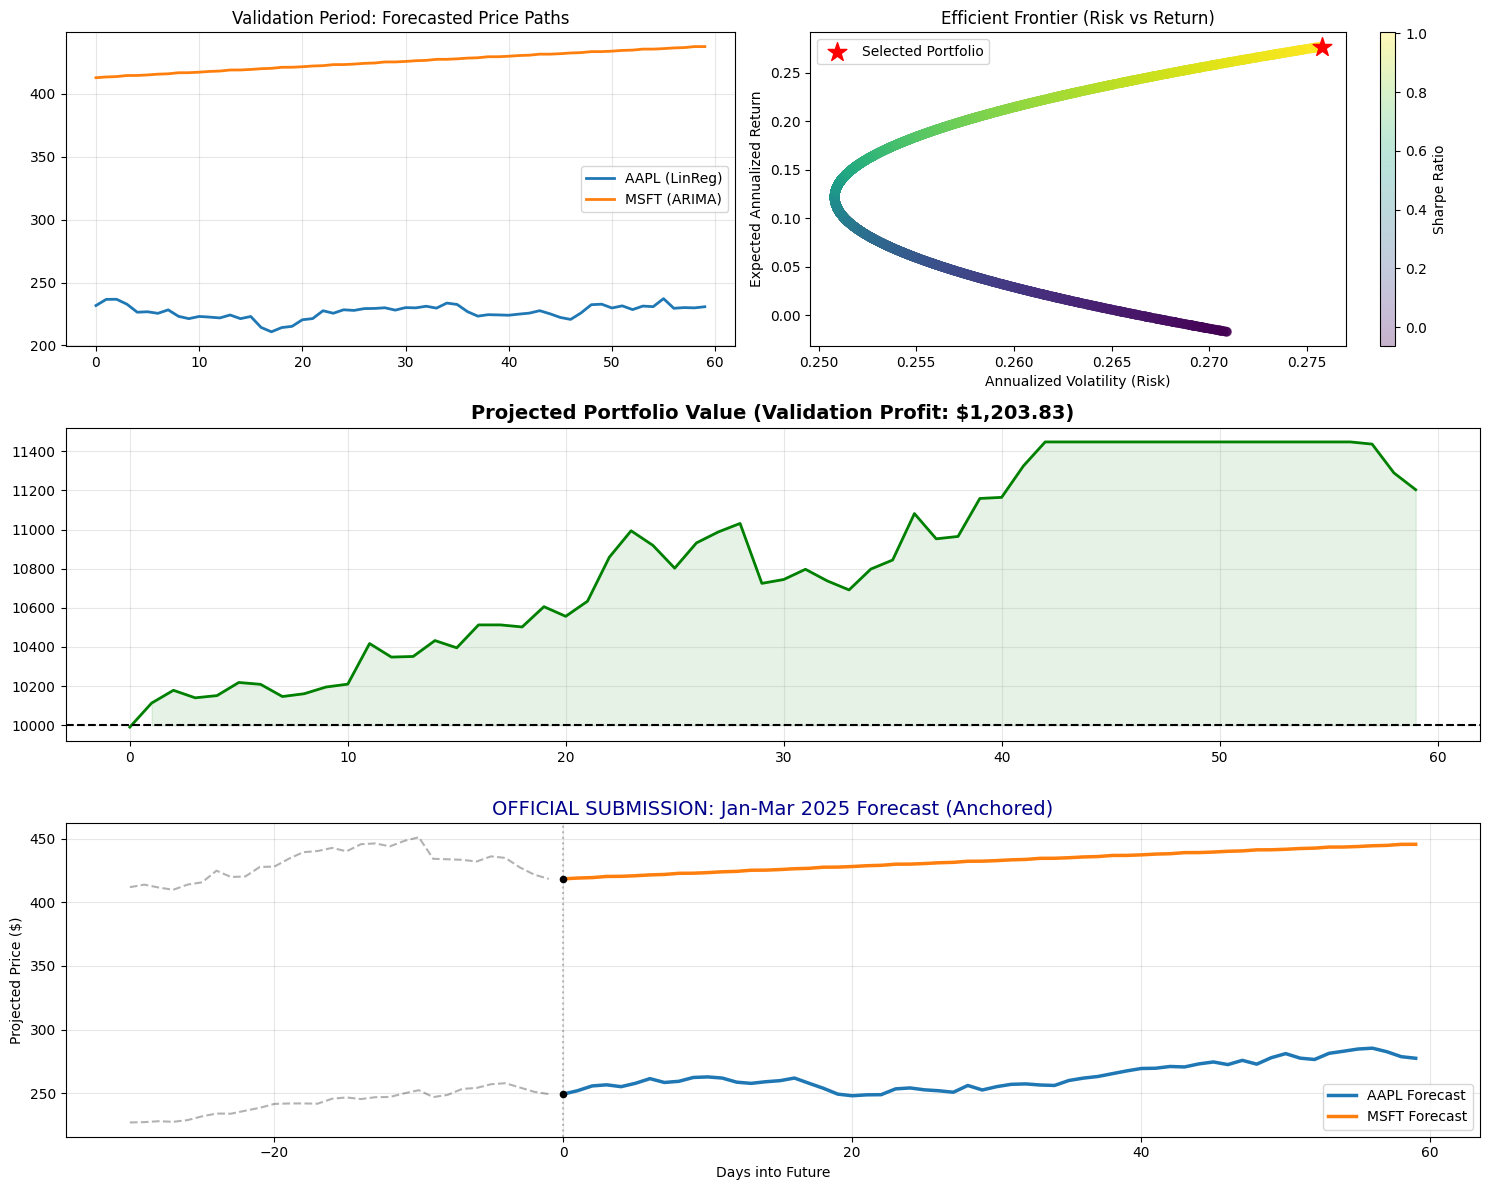

>>> Submission file 'Phantom_Troupe_Submission.csv' saved.


In [22]:
def show_final_report(allocation, results, threshold, capital, stocks_list, data_dict):
    print(f"\n{'='*50}\n FINAL REPORT (Phantom Troupe) \n{'='*50}")
    
    # --- 1. Re-calculate Metrics for Efficient Frontier Plot ---
    # We need to regenerate expected returns and covariance based on the results
    expected_returns = []
    for ticker in stocks_list:
        winner = results[ticker]['winner']
        preds = results[ticker]['preds'][winner]
        # Annualized Return based on the 60-day validation forecast
        roi = (preds[-1] - preds[0]) / preds[0]
        annualized_roi = (1 + roi) ** (252 / 60) - 1
        expected_returns.append(annualized_roi)
    
    expected_returns = np.array(expected_returns)
    price_dict = {t: data_dict[t]['Close'].values.flatten() for t in stocks_list}
    price_df = pd.DataFrame(price_dict)
    cov_mat = price_df.pct_change().dropna().cov() * 252
    
    # Weights array for plotting the red star
    opt_weights = np.array([allocation[t] for t in stocks_list])

    # --- 2. Run Backtest & Portfolio Evaluation ---
    evaluator = PortfolioEvaluator(starting_capital=capital, allocation=allocation)
    
    print("\n1. OPTIMAL ALLOCATION & STRATEGY:")
    print(f"   Trading Threshold: {threshold*100:.2f}%")
    for ticker, weight in allocation.items():
        print(f"   - {ticker}: {weight*100:.2f}%")
        winner = results[ticker]['winner']
        # Run backtest on validation set
        bt = Backtest(starting_capital=capital)
        bt.run_strategy(results[ticker]['actual'], results[ticker]['preds'][winner], threshold=threshold)
        evaluator.add_stock(ticker, bt, winner)
        
    evaluator.show_report()
    metrics = evaluator.compute_portfolio_performance()
    profit = metrics['profit_$']

    # --- 3. VISUALIZATION DASHBOARD (Merged Plots) ---
    fig = plt.figure(figsize=(15, 12)) 
    gs = fig.add_gridspec(3, 2) # 3 Rows: 1.Forecasts/Frontier, 2.Value, 3.Future

    # Plot A: Validation Forecasts
    ax1 = fig.add_subplot(gs[0, 0])
    for ticker in stocks_list:
        winner = results[ticker]['winner']
        preds = results[ticker]['preds'][winner]
        ax1.plot(preds, label=f"{ticker} ({winner})", linewidth=2)
    ax1.set_title("Validation Period: Forecasted Price Paths")
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # Plot B: Efficient Frontier
    ax2 = fig.add_subplot(gs[0, 1])
    p_rets, p_vols = [], []
    # Monte Carlo Sim (10,000 runs for density)
    for _ in range(10000):
        weights = np.random.random(len(stocks_list))
        weights /= np.sum(weights)
        p_ret = np.sum(expected_returns * weights)
        p_vol = np.sqrt(np.dot(weights.T, np.dot(cov_mat, weights)))
        p_rets.append(p_ret)
        p_vols.append(p_vol)

    sc = ax2.scatter(p_vols, p_rets, c=np.array(p_rets)/np.array(p_vols), cmap='viridis', alpha=0.3)
    
    # Plot Optimal Point (Red Star)
    opt_ret = np.sum(expected_returns * opt_weights)
    opt_vol = np.sqrt(np.dot(opt_weights.T, np.dot(cov_mat, opt_weights)))
    ax2.scatter(opt_vol, opt_ret, marker='*', color='red', s=200, label='Selected Portfolio')
    
    ax2.set_title("Efficient Frontier (Risk vs Return)")
    ax2.set_xlabel("Annualized Volatility (Risk)")
    ax2.set_ylabel("Expected Annualized Return")
    plt.colorbar(sc, ax=ax2, label='Sharpe Ratio')
    ax2.legend()

    # Plot C: Portfolio Value Over Time
    ax3 = fig.add_subplot(gs[1, :])
    port_values = metrics['portfolio_values']
    ax3.plot(port_values, color='green', linewidth=2)
    ax3.axhline(capital, color='black', linestyle='--')
    # Fill Logic (Green for profit, Red for loss)
    x_range = range(len(port_values))
    ax3.fill_between(x_range, capital, port_values, where=[v>=capital for v in port_values], color='green', alpha=0.1)
    ax3.fill_between(x_range, capital, port_values, where=[v<capital for v in port_values], color='red', alpha=0.1)
    ax3.set_title(f"Projected Portfolio Value (Validation Profit: ${profit:,.2f})", fontsize=14, fontweight='bold')
    ax3.grid(True, alpha=0.3)

    # Plot D: FUTURE FORECAST (The Submission)
    ax4 = fig.add_subplot(gs[2, :])
    
    for ticker, preds in future_predictions.items():
        # 1. Plot the Future (The Fix is inside 'preds')
        ax4.plot(preds, label=f"{ticker} Forecast", linewidth=2.5)
        
        # 2. Plot the History (Visual Proof of Anchoring)
        # We grab the last 30 days of actual data to show the connection
        history = data_dict[ticker]['Close'].iloc[-30:].values
        # Create an x-axis for history that ends at 0 (today)
        hist_x = np.arange(-len(history), 0)
        
        ax4.plot(hist_x, history, color='black', alpha=0.3, linestyle='--')
        
        # Optional: Add a dot at the connection point to highlight the "Anchor"
        ax4.scatter([0], [history[-1]], color='black', s=20, zorder=5)

    ax4.set_title("OFFICIAL SUBMISSION: Jan-Mar 2025 Forecast (Anchored)", fontsize=14, color='darkblue')
    ax4.set_xlabel("Days into Future")
    ax4.set_ylabel("Projected Price ($)")
    ax4.axvline(0, color='gray', linestyle=':', alpha=0.5) # The "Today" line
    ax4.legend()
    ax4.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()
    
    # Save Submission
    submission_df = pd.DataFrame(future_predictions)
    submission_df.to_csv("Phantom_Troupe_Submission.csv")
    print(">>> Submission file 'Phantom_Troupe_Submission.csv' saved.")

# Execute with all required arguments
show_final_report(allocation_dict, results, optimal_threshold, CAPITAL, MY_STOCKS, stock_data)